# Host Classification
- Class-Conditional Validity Envelopes - Rather than constructing a single 35-dimensional envelope  
- No Imputation
- No Empty Sets

In [1]:
import os
import pickle
import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

### Loading the Data

In [2]:
alpha = 0.1
number_of_bins = 5

In [3]:
DATA_DIR = "../../Data"
SCORES_PATH = f"{DATA_DIR}/phage_host_scores.parquet"
METADATA_PATH = f"{DATA_DIR}/metadata.csv"
GRAM_PRED_PATH = "../gram_type_predictions.csv"

print("Loading phage-level scores ...")
t0 = time.time()
phage_scores = pd.read_parquet(SCORES_PATH)
print(f"  shape : {phage_scores.shape}  ({time.time()-t0:.1f}s)")

print("Loading metadata ...")
t0 = time.time()
meta_df = pd.read_csv(METADATA_PATH, index_col="proteinID")
print(f"  shape : {meta_df.shape}  ({time.time()-t0:.1f}s)")

print("Loading gram predictions ...")
t0 = time.time()
gram_pred_df = pd.read_csv(GRAM_PRED_PATH).set_index("accession")
for col in ["pred_gramneg", "pred_grampos"]:
    if gram_pred_df[col].dtype != bool:
        gram_pred_df[col] = (
            gram_pred_df[col].astype(str).str.strip().str.lower()
            .map({"true": True, "false": False, "1": True, "0": False})
        )
    assert gram_pred_df[col].isna().sum() == 0, f"{col}: unmapped/NaN values after normalization"
    assert gram_pred_df[col].dtype == bool, f"{col}: did not convert cleanly to bool"
print(f"  shape : {gram_pred_df.shape}  ({time.time()-t0:.1f}s)")

Loading phage-level scores ...
  shape : (18443, 2036)  (0.6s)
Loading metadata ...
  shape : (1853074, 8)  (3.5s)
Loading gram predictions ...
  shape : (18474, 2)  (0.0s)


#### Joining scores with labels

In [4]:
phage_meta = meta_df.reset_index().groupby("accession")[["host", "host_type", "split"]].first()
phage_df = phage_scores.join(phage_meta, how="inner")
phage_df["split"] = phage_df["split"].astype(int)

print(f"\nPhage-level shape after join: {phage_df.shape}")
print("\nSplit distribution:")
print(phage_df["split"].value_counts().sort_index())
print("\nHost distribution (top 15):")
print(phage_df["host"].value_counts().head(15))


Phage-level shape after join: (18443, 2039)

Split distribution:
split
0    4422
1    3169
2    3638
3    3584
4    3630
Name: count, dtype: int64

Host distribution (top 15):
host
Mycobacterium     2352
Escherichia       2254
Pseudomonas       1023
Klebsiella         966
Salmonella         958
Vibrio             917
Streptococcus      740
Gordonia           657
Staphylococcus     652
Microbacterium     545
Bacillus           440
Ralstonia          412
Arthrobacter       397
Synechococcus      392
Lactococcus        388
Name: count, dtype: int64


#### Identifying the score columns and host 

In [5]:
score_cols = [c for c in phage_scores.columns]

# Host genus = prefix before first underscore
all_hosts = sorted(set(c.split("_")[0] for c in score_cols))
print(f"Host: {len(all_hosts)}")
print(all_hosts)

# Map each host to its column indices
host_col_map = {h: [i for i, c in enumerate(score_cols) if c.split("_")[0] == h] for h in all_hosts}
print("\nColumns per host (sample):")
for h in all_hosts:
    print(f"  {h}: {len(host_col_map[h])} columns")

Host: 54
['Campylobacter', 'Caulobacter', 'Cellulophaga', 'Citrobacter', 'Clostridioides', 'Clostridium', 'Corynebacterium', 'Cronobacter', 'Dickeya', 'Edwardsiella', 'Enterobacter', 'Enterococcus', 'Erwinia', 'Escherichia', 'Flavobacterium', 'Gordonia', 'Haloarcula', 'Halorubrum', 'Klebsiella', 'Lacticaseibacillus', 'Lactobacillus', 'Lactococcus', 'Listeria', 'Microbacterium', 'Microcystis', 'Mycobacterium', 'Paenibacillus', 'Pantoea', 'Pectobacterium', 'Pelagibacter', 'Prochlorococcus', 'Propionibacterium', 'Proteus', 'Providencia', 'Pseudoalteromonas', 'Pseudomonas', 'Ralstonia', 'Rhizobium', 'Rhodobacter', 'Roseobacter', 'Salmonella', 'Serratia', 'Shewanella', 'Shigella', 'Sinorhizobium', 'Staphylococcus', 'Stenotrophomonas', 'Streptococcus', 'Streptomyces', 'Sulfolobus', 'Synechococcus', 'Vibrio', 'Xanthomonas', 'Yersinia']

Columns per host (sample):
  Campylobacter: 40 columns
  Caulobacter: 40 columns
  Cellulophaga: 36 columns
  Citrobacter: 40 columns
  Clostridioides: 36 col

### Gram-Type Setup
Moved here (before train/test split, before any envelope is built) instead of bolted on at the end. Two things are computed:

1. `host_to_gramtype` / `gram_pos_hosts` / `gram_neg_hosts` — ground truth, from metadata.
2. `candidate_hosts_for(accession)` — the actually-usable restriction at test time, based on the **predicted** gram-type from `Gram_Classification.ipynb`'s output, not the ground truth (you don't know ground truth at prediction time).

Added a check that was missing before: whether every host actually has a gram-type label, and whether the label strings (`"gram-pos"` / `"gram-neg"`) actually match what's in the metadata. If this prints hosts with no gram-type or the counts look off, stop — the restriction below will silently fall back to `all_hosts` for those and the whole exercise does nothing for them.

In [6]:
# Ground-truth host -> gram-type lookup (from metadata, not a prediction)
host_to_gramtype = (
    phage_df.dropna(subset=["host_type"])
    .drop_duplicates("host")
    .set_index("host")["host_type"]
    .to_dict()
)
print("Observed host_type values in metadata:", phage_df["host_type"].dropna().unique().tolist())

gram_pos_hosts = sorted(h for h in all_hosts if host_to_gramtype.get(h) == "gram-pos")
gram_neg_hosts = sorted(h for h in all_hosts if host_to_gramtype.get(h) == "gram-neg")

missing_gram = [h for h in all_hosts if h not in host_to_gramtype]
print(f"Gram-pos hosts: {len(gram_pos_hosts)}  |  Gram-neg hosts: {len(gram_neg_hosts)}")
if missing_gram:
    print(f"Missing Gram labels for: {missing_gram}")
assert not missing_gram, (
    "Hosts with no gram-type label will silently fall back to all_hosts in "
    "candidate_hosts_for() — fix the metadata before continuing."
)

observed_values = set(phage_df["host_type"].dropna().unique())
assert observed_values <= {"gram-pos", "gram-neg"}, (
    f"Unexpected host_type values: {observed_values - {'gram-pos', 'gram-neg'}}"
)

Observed host_type values in metadata: ['gram-neg', 'gram-pos']
Gram-pos hosts: 16  |  Gram-neg hosts: 38


In [7]:
def candidate_hosts_for(accession):
    """
    Restricts candidate host targets strictly based on the model's 
    predicted gram-type output.
    """
    if accession not in gram_pred_df.index:
        return all_hosts
    row = gram_pred_df.loc[accession]
    allowed = []
    if row["pred_gramneg"]: allowed += gram_neg_hosts
    if row["pred_grampos"]: allowed += gram_pos_hosts
    return allowed if allowed else all_hosts

### Train Test Split

In [8]:
phage_df = phage_df[phage_df["host"].isin(all_hosts)].copy()

train_df = phage_df[phage_df["split"] != 0].copy()
test_df = phage_df[phage_df["split"] == 0].copy()

print(f"Training phages (folds 1-4) : {len(train_df)}")
print(f"Test phages     (fold 0)    : {len(test_df)}")
print("\nTest host distribution:")
print(test_df["host"].value_counts())

Training phages (folds 1-4) : 11694
Test phages     (fold 0)    : 3944

Test host distribution:
host
Escherichia           856
Mycobacterium         497
Vibrio                279
Staphylococcus        235
Pseudomonas           196
Ralstonia             183
Salmonella            182
Klebsiella            168
Synechococcus         168
Streptococcus         160
Microbacterium        123
Propionibacterium     106
Gordonia               81
Enterococcus           72
Sulfolobus             55
Lactococcus            51
Shigella               46
Erwinia                38
Pelagibacter           31
Clostridium            29
Halorubrum             28
Flavobacterium         28
Yersinia               27
Streptomyces           22
Lactobacillus          21
Caulobacter            20
Rhizobium              19
Listeria               17
Cronobacter            16
Roseobacter            15
Enterobacter           15
Serratia               15
Pseudoalteromonas      14
Haloarcula             13
Corynebacterium

### Score characteristics
 -  For each host, the columns specific to that host should have higher mean scores for phages that actually infect that host.

In [9]:
print("Mean score at true-host columns vs all columns (training set):")
sample_hosts = all_hosts[:5]
for h in sample_hosts:
    h_idx = host_col_map[h]
    mask_h = train_df["host"] == h
    if mask_h.sum() == 0:
        continue
    true_host_mean = np.nanmean(train_df.loc[mask_h, score_cols].values[:, h_idx])
    all_mean = np.nanmean(train_df.loc[mask_h, score_cols].values)
    print(f"  {h}: true-host cols mean={true_host_mean:.3f}, all cols mean={all_mean:.3f}, n={mask_h.sum()}")

Mean score at true-host columns vs all columns (training set):
  Campylobacter: true-host cols mean=0.207, all cols mean=0.052, n=96
  Caulobacter: true-host cols mean=0.271, all cols mean=0.058, n=31
  Cellulophaga: true-host cols mean=0.262, all cols mean=0.051, n=45
  Citrobacter: true-host cols mean=0.072, all cols mean=0.053, n=39
  Clostridioides: true-host cols mean=0.368, all cols mean=0.091, n=17


### Score Transformation
 -  For host classification: NC = 1 - raw_score
 - High raw score = strong infection evidence = low nonconformity

In [10]:
def raw_to_nc(raw_array):
    """Transforming scores to NC: NC = 1 - raw_score"""
    return np.where(np.isnan(raw_array), np.nan, 1.0 - raw_array)

train_raw = train_df[score_cols].values   # (n_train, K)
test_raw = test_df[score_cols].values    # (n_test,  K)
train_labels = train_df["host"].to_numpy(dtype=str)
test_labels = test_df["host"].to_numpy(dtype=str)

train_nc = raw_to_nc(train_raw)
test_nc = raw_to_nc(test_raw)

print(f"Train NC shape: {train_nc.shape}")
print(f"Test NC shape : {test_nc.shape}")
print(f"NaN fraction in train NC: {np.isnan(train_nc).mean():.3f}")
print(f"NaN fraction in test NC : {np.isnan(test_nc).mean():.3f}")

Train NC shape: (11694, 2036)
Test NC shape : (3944, 2036)
NaN fraction in train NC: 0.623
NaN fraction in test NC : 0.631


### Functions

In [11]:
def quantile_for_class(tau_scores, labels, cls, alpha):
    vals = np.sort(tau_scores[labels == cls])
    n = len(vals)
    if n == 0:
        return 0.0
    idx = int(np.ceil((n + 1) * (1 - alpha))) - 1
    return vals[np.clip(idx, 0, n - 1)]

def compute_t_hat_multiclass(tau_scores, labels, classes, alpha):
    """t_hat = max over all classes of the per-class (1-alpha) quantile."""
    return max(quantile_for_class(tau_scores, labels, c, alpha) for c in classes)

#### 1D Collapsed Envelope

In [12]:
def collapsed_build_envelope(S1, S2, labels_S2, classes, alpha):
    S1_1d = np.nanmean(S1, axis=1, keepdims=True)
    S2_1d = np.nanmean(S2, axis=1, keepdims=True)
    q_tilde = np.nanquantile(S1_1d, 1 - alpha)
    tau_scores = (S2_1d / (q_tilde + 1e-12)).ravel()
    t_hat = compute_t_hat_multiclass(tau_scores, labels_S2, classes, alpha)
    return {"q_tilde": q_tilde, "t_hat": t_hat, "method": "collapsed"}

def collapsed_tau(scores, envelope):
    scores_1d = np.nanmean(scores, axis=1)
    return scores_1d / (envelope["q_tilde"] * envelope["t_hat"] + 1e-12)

def collapsed_is_in_region(scores, envelope):
    return np.nanmean(scores, axis=1) <= envelope["q_tilde"] * envelope["t_hat"]

#### Radial Envelope

In [13]:
def sample_positive_sphere(rng, M, K):
    V = np.abs(rng.standard_normal((M, K)))
    return V / (np.linalg.norm(V, axis=1, keepdims=True) + 1e-12)

# def radial_build_envelope(S1, S2, labels_S2, classes, alpha, M=200, delta_deg=75, rng=None):
#     if rng is None:
#         raise ValueError("radial_build_envelope requires an explicit rng for reproducibility")
#     N1, K = S1.shape
#     U = sample_positive_sphere(rng, M, K)
#     cos_thresh = np.cos(np.radians(delta_deg))

#     mags = np.array([np.linalg.norm(S1[n, ~np.isnan(S1[n])]) for n in range(N1)])
#     dirs = np.zeros((N1, K))
#     for n in range(N1):
#         valid = ~np.isnan(S1[n])
#         if mags[n] > 1e-12:
#             dirs[n, valid] = S1[n, valid] / mags[n]

    q_tilde = np.zeros(M)
    # for m in range(M):
    #     cos_sims = dirs @ U[m]
    #     nearby = cos_sims >= cos_thresh
    #     src_mags = mags[nearby] if nearby.sum() > 5 else mags
    #     q_tilde[m] = np.quantile(src_mags, 1 - alpha)

    fallback_count = 0
    for m in range(M):
        cos_sims = dirs @ U[m]
        nearby = cos_sims >= cos_thresh
        if nearby.sum() <= 5:
            fallback_count += 1
        src_mags = mags[nearby] if nearby.sum() > 5 else mags
        q_tilde[m] = np.quantile(src_mags, 1 - alpha)
    print(f"  [radial diag] fallback triggered in {fallback_count}/{M} directions")

    # N2 = S2.shape[0]
    # tau_scores = np.zeros(N2)
    # boundary = U * q_tilde[:, None]
    # for n in range(N2):
    #     valid = ~np.isnan(S2[n])
    #     if valid.sum() == 0:
    #         tau_scores[n] = 0.0
    #         continue
    #     ratios_m = (S2[n, valid][None, :] / (boundary[:, valid] + 1e-12)).max(axis=1)
    #     tau_scores[n] = ratios_m.min()

    # t_hat = compute_t_hat_multiclass(tau_scores, labels_S2, classes, alpha)
    # return {"U": U, "q_tilde": q_tilde, "t_hat": t_hat, "method": "radial"}


def radial_build_envelope(S1, S2, labels_S2, classes, alpha, M=200, neighbor_frac=0.2, rng=None):
    if rng is None:
        raise ValueError("radial_build_envelope requires an explicit rng for reproducibility")
    N1, K = S1.shape
    U = sample_positive_sphere(rng, M, K)

    mags = np.array([np.linalg.norm(S1[n, ~np.isnan(S1[n])]) for n in range(N1)])
    dirs = np.zeros((N1, K))
    for n in range(N1):
        valid = ~np.isnan(S1[n])
        if mags[n] > 1e-12:
            dirs[n, valid] = S1[n, valid] / mags[n]

    q_tilde = np.zeros(M)
    k_neighbors = max(10, int(neighbor_frac * N1))
    for m in range(M):
        cos_sims = dirs @ U[m]
        nearby_idx = np.argsort(cos_sims)[-k_neighbors:]   # top-k closest directions, always
        src_mags = mags[nearby_idx]
        q_tilde[m] = np.quantile(src_mags, 1 - alpha)
        
    N2 = S2.shape[0]
    tau_scores = np.zeros(N2)
    boundary = U * q_tilde[:, None]
    for n in range(N2):
        valid = ~np.isnan(S2[n])
        if valid.sum() == 0:
            tau_scores[n] = 0.0
            continue
        ratios_m = (S2[n, valid][None, :] / (boundary[:, valid] + 1e-12)).max(axis=1)
        tau_scores[n] = ratios_m.min()

    t_hat = compute_t_hat_multiclass(tau_scores, labels_S2, classes, alpha)
    return {"U": U, "q_tilde": q_tilde, "t_hat": t_hat, "method": "radial"}

def radial_tau(scores, envelope):
    U, q_tilde, t_hat = envelope["U"], envelope["q_tilde"], envelope["t_hat"]
    boundary = U * (q_tilde * t_hat)[:, None]
    N = scores.shape[0]
    tau = np.zeros(N)
    for n in range(N):
        valid = ~np.isnan(scores[n])
        if valid.sum() == 0:
            tau[n] = 0.0
            continue
        ratios_m = (scores[n, valid][None, :] / (boundary[:, valid] + 1e-12)).max(axis=1)
        tau[n] = ratios_m.min()
    return tau

def radial_is_in_region(scores, envelope):
    U, q_tilde, t_hat = envelope["U"], envelope["q_tilde"], envelope["t_hat"]
    boundary = U * (q_tilde * t_hat)[:, None]
    N = scores.shape[0]
    inside = np.zeros(N, dtype=bool)
    for n in range(N):
        valid = ~np.isnan(scores[n])
        if valid.sum() == 0:
            inside[n] = True
            continue
        inside[n] = np.any(np.all(scores[n, valid][None, :] <= boundary[:, valid], axis=1))
    return inside

#### Strip Envelope

In [14]:
def strip_shape_discovery(S1, alpha, M):
    N1, K = S1.shape
    bin_edges = np.array([
        np.linspace(np.nanmin(S1[:, j]), np.nanmax(S1[:, j]), M + 1)
        for j in range(K)
    ])
    limits = np.zeros((K, K, M))
    marginal_quantiles = np.array([
        np.nanquantile(S1[:, i], 1 - alpha) for i in range(K)
    ])
    # FIX 1: a column with zero observations in S1 has no valid marginal quantile —
    # fall back to 1.0 (the worst-case / max NC value), so it never poisons downstream limits with NaN
    marginal_quantiles = np.where(np.isnan(marginal_quantiles), 1.0, marginal_quantiles)

    for j in range(K):
        for m in range(M):
            lo, hi = bin_edges[j, m], bin_edges[j, m + 1]
            in_strip = (~np.isnan(S1[:, j])) & (S1[:, j] >= lo) & (S1[:, j] < hi)
            for i in range(K):
                if i == j:
                    continue
                src_mask = in_strip & (~np.isnan(S1[:, i]))
                if src_mask.sum() >= 3:
                    limits[j, i, m] = np.quantile(S1[src_mask, i], 1 - alpha)
                else:
                    non_nan_i = S1[~np.isnan(S1[:, i]), i]
                    limits[j, i, m] = (
                        np.quantile(non_nan_i, 1 - alpha)
                        if len(non_nan_i) > 0 else marginal_quantiles[i]
                    )

    for j in range(K):
        for i in range(K):
            if i == j:
               continue
            for m in range(M - 2, -1, -1):
               limits[j, i, m] = max(limits[j, i, m], limits[j, i, m + 1])
    return bin_edges, limits, marginal_quantiles

def get_bin_indices(scores, bin_edges):
    K = scores.shape[1]
    M = bin_edges.shape[1] - 1
    return np.array([np.clip(np.where(np.isnan(scores[:, j]), 0, np.digitize(scores[:, j], bin_edges[j]) - 1), 0, M - 1) for j in range(K)]).T


def strip_tau_scores(S, bin_edges, limits, marginal_quantiles):
    N, K = S.shape
    bin_idx = get_bin_indices(S, bin_edges)

    j_idx = np.arange(K)[None, :, None]
    i_idx = np.arange(K)[None, None, :]
    m_idx = bin_idx[:, :, None]

    lims = limits[j_idx, i_idx, m_idx]

    S_i = S[:, np.newaxis, :]
    S_j = S[:, :, np.newaxis]

    nan_i = np.isnan(S_i)
    nan_j = np.isnan(S_j)

    mq = marginal_quantiles[np.newaxis, np.newaxis, :]

    ratio = np.zeros((N, K, K))
    both_avail = (~nan_i) & (~nan_j)
    miss_i = nan_i & (~nan_j)

    ratio = np.where(both_avail, np.broadcast_to(S_i, (N, K, K)) / (lims + 1e-12), ratio)
    ratio = np.where(miss_i, np.broadcast_to(mq, (N, K, K)) / (lims + 1e-12), ratio)

    diag_mask = np.eye(K, dtype=bool)[np.newaxis, :, :]
    ratio = np.where(diag_mask, 0.0, ratio)

    # FIX 2: use nanmax, not max — a stray NaN limit shouldn't poison the whole row's score.
    # Diagonal is always 0.0 (never NaN), so nanmax always has a valid value to fall back on.
    return np.nanmax(ratio, axis=(1, 2))



def strip_build_envelope(S1, S2, labels_S2, classes, alpha, M= number_of_bins):
    bin_edges, limits, marginal_quantiles = strip_shape_discovery(S1, alpha, M)
    tau_scores = strip_tau_scores(S2, bin_edges, limits, marginal_quantiles)
    t_hat = compute_t_hat_multiclass(tau_scores, labels_S2, classes, alpha)
    return {
        "bin_edges": bin_edges,
        "limits": limits,
        "marginal_quantiles": marginal_quantiles,
        "t_hat": t_hat,
        "method": "strip"
    }

def strip_tau(scores, envelope):
    raw = strip_tau_scores(scores, envelope["bin_edges"], envelope["limits"], envelope["marginal_quantiles"])
    return raw / (envelope["t_hat"] + 1e-12)

def strip_is_in_region(scores, envelope):
    tau = strip_tau_scores(scores, envelope["bin_edges"], envelope["limits"], envelope["marginal_quantiles"])
    return tau <= envelope["t_hat"]

def is_in_region(scores, envelope):
    if envelope["method"] == "radial":
        return radial_is_in_region(scores, envelope)
    elif envelope["method"] == "strip":
        return strip_is_in_region(scores, envelope)
    return collapsed_is_in_region(scores, envelope)

def compute_tau(scores, envelope):
    if envelope["method"] == "collapsed":
        return collapsed_tau(scores, envelope)
    elif envelope["method"] == "strip":
        return strip_tau(scores, envelope)
    return radial_tau(scores, envelope)

### Envelope construction
- Building an envelope per host. 
- For each host
    - Extract only the K_h columns specific to host h
    - Build a separate envelope calibrated on training phages with true host h
    - At test time, check each hypothesis h using its K_h-dim NC sub-vector

In [15]:
# def build_per_host_envelopes(train_nc, train_labels, all_hosts, score_cols, host_col_map, alpha,
#                               method="collapsed", seed=42):
#     rng = np.random.default_rng(seed)
#     envelopes = {}

#     for h in all_hosts:
#         h_idx = host_col_map[h]
#         if len(h_idx) == 0:
#             continue

#         mask_h = train_labels == h
#         n_h = mask_h.sum()
#         if n_h < 6:
#             print(f"  SKIP {h}: only {n_h} training phages")
#             continue

#         train_nc_h = train_nc[mask_h][:, h_idx]

#         idx = rng.permutation(n_h)
#         half = n_h // 2
#         S1 = train_nc_h[idx[:half]]
#         S2 = train_nc_h[idx[half:]]
#         labels_S2 = np.array([h] * len(S2))

#         if method == "collapsed":
#             env = collapsed_build_envelope(S1, S2, labels_S2, [h], alpha)
#         elif method == "radial":
#             env = radial_build_envelope(S1, S2, labels_S2, [h], alpha, rng=rng)   # add rng=rng
#         else:
#             env = strip_build_envelope(S1, S2, labels_S2, [h], alpha)

#         envelopes[h] = {"envelope": env, "col_indices": h_idx}

#     print(f"  Built {len(envelopes)} host envelopes")
#     return envelopes

def build_per_host_envelopes(train_nc, train_labels, all_hosts, score_cols, host_col_map, alpha,
                              method="collapsed", seed=42):
    rng = np.random.default_rng(seed)
    envelopes = {}

    for h in all_hosts:
        h_idx_full = host_col_map[h]
        if len(h_idx_full) == 0:
            continue

        mask_h = train_labels == h
        n_h = mask_h.sum()
        if n_h < 6:
            print(f"  SKIP {h}: only {n_h} training phages")
            continue

        train_nc_h_full = train_nc[mask_h][:, h_idx_full]

        # NEW: drop any column that has zero data for this host entirely,
        # instead of keeping it and patching with a sentinel downstream.
        has_data = ~np.isnan(train_nc_h_full).all(axis=0)
        dropped = np.array(h_idx_full)[~has_data]
        if len(dropped) > 0:
            print(f"  {h}: dropping {len(dropped)} column(s) with zero data -> "
                  f"{np.array(score_cols)[dropped].tolist()}")

        h_idx = list(np.array(h_idx_full)[has_data])
        train_nc_h = train_nc_h_full[:, has_data]

        idx = rng.permutation(n_h)
        half = n_h // 2
        S1 = train_nc_h[idx[:half]]
        S2 = train_nc_h[idx[half:]]
        labels_S2 = np.array([h] * len(S2))

        if method == "collapsed":
            env = collapsed_build_envelope(S1, S2, labels_S2, [h], alpha)
        elif method == "radial":
            # Pass the rng instance here
            env = radial_build_envelope(S1, S2, labels_S2, [h], alpha, rng=rng)
        else:
            env = strip_build_envelope(S1, S2, labels_S2, [h], alpha)
        envelopes[h] = {"envelope": env, "col_indices": h_idx}   # reduced h_idx

    print(f"  Built {len(envelopes)} host envelopes")
    return envelopes

### Host prediction

In [16]:
def predict_host(test_raw, per_host_envelopes, active_hosts_list):
    N = len(test_raw)
    n_h = len(active_hosts_list)

    inside_matrix = np.zeros((N, n_h), dtype=bool)
    tau_matrix = np.zeros((N, n_h), dtype=float)

    for j, h in enumerate(active_hosts_list):
        h_idx = per_host_envelopes[h]["col_indices"]
        env_h = per_host_envelopes[h]["envelope"]

        raw_h = test_raw[:, h_idx]
        nc_h = np.where(np.isnan(raw_h), np.nan, 1.0 - raw_h)

        inside_matrix[:, j] = is_in_region(nc_h, env_h)
        tau_matrix[:, j] = compute_tau(nc_h, env_h)

    results = []
    for i in range(N):
        pred_set = [active_hosts_list[j] for j in range(n_h) if inside_matrix[i, j]]
        forced = False
        if len(pred_set) == 0:
            forced = True
            best_j = int(np.argmin(tau_matrix[i]))
            pred_set = [active_hosts_list[best_j]]
        results.append({
            "prediction_set": pred_set,
            "forced":         forced,
            "tau_per_host":   {active_hosts_list[j]: tau_matrix[i, j] for j in range(n_h)}
        })
    return results

#### Evaluation

In [17]:
def evaluate_multiclass(results, true_labels, all_hosts, alpha):
    n = len(results)
    set_sizes = [len(r["prediction_set"]) for r in results]
    covered = sum(true_labels[i] in r["prediction_set"] for i, r in enumerate(results))
    forced = sum(r["forced"] for r in results)
    singletons = [(r, true_labels[i]) for i, r in enumerate(results) if len(r["prediction_set"]) == 1]

    correct_singletons = sum(r["prediction_set"][0] == lbl for r, lbl in singletons)

    per_host_coverage = {}
    for h in all_hosts:
        h_idx = [i for i, lbl in enumerate(true_labels) if lbl == h]
        if not h_idx:
            continue
        per_host_coverage[h] = sum(true_labels[i] in results[i]["prediction_set"] for i in h_idx) / len(h_idx)

    return {
        "coverage":           covered / n,
        "avg_set_size":       np.mean(set_sizes),
        "singleton_rate":     len(singletons) / n,
        "singleton_accuracy": (correct_singletons / len(singletons) if singletons else None),
        "forced_rate":        forced / n,
        "set_sizes":          set_sizes,
        "per_host_coverage":  per_host_coverage,
        "min_host_coverage":  min(per_host_coverage.values()) if per_host_coverage else None,
    }

### Evaluating on split 0 phages

In [18]:
print("\n" + "="*60)
print(" BASELINE — no gram-type filtering (kept only for comparison) ")
print("="*60)
print("\nBuilding collapsed envelopes...")
baseline_envs_c = build_per_host_envelopes(          # renamed from per_host_envs_c
    train_nc, train_labels, all_hosts, score_cols, host_col_map, alpha,
    method="collapsed", seed=42)
collapsed_results_unrestricted = predict_host(test_raw, baseline_envs_c, all_hosts)
collapsed_metrics_unrestricted = evaluate_multiclass(
    collapsed_results_unrestricted, test_labels, all_hosts, alpha)
print(f"  coverage={collapsed_metrics_unrestricted['coverage']:.3f}  "
      f"avg_set_size={collapsed_metrics_unrestricted['avg_set_size']:.2f}")


 BASELINE — no gram-type filtering (kept only for comparison) 

Building collapsed envelopes...
  Campylobacter: dropping 1 column(s) with zero data -> ['Campylobacter_ejection']
  Cellulophaga: dropping 1 column(s) with zero data -> ['Cellulophaga_val']
  Clostridioides: dropping 1 column(s) with zero data -> ['Clostridioides_primase']
  Corynebacterium: dropping 1 column(s) with zero data -> ['Corynebacterium_baseplate']
  Edwardsiella: dropping 3 column(s) with zero data -> ['Edwardsiella_lysis_inhibitor', 'Edwardsiella_replication_initiation', 'Edwardsiella_toxin']
  Enterobacter: dropping 1 column(s) with zero data -> ['Enterobacter_sir2']
  Flavobacterium: dropping 2 column(s) with zero data -> ['Flavobacterium_super_infection', 'Flavobacterium_toxin']
  Gordonia: dropping 1 column(s) with zero data -> ['Gordonia_ejection']
  Haloarcula: dropping 2 column(s) with zero data -> ['Haloarcula_spanin', 'Haloarcula_tail_sheath']
  Halorubrum: dropping 3 column(s) with zero data -> ['H

### Prediction

In [19]:
print("\n" + "="*60)
print(" GRAM-TYPE FILTERED EVALUATION ")
print("="*60)

# print("\nBuilding collapsed envelopes...")
per_host_envs_c = baseline_envs_c   # identical build (collapsed, seed=42) — reuse, don't recompute

# print("\nBuilding radial envelopes...")
per_host_envs_r = build_per_host_envelopes(train_nc, train_labels, all_hosts, score_cols, host_col_map, alpha, method="radial")

# print("\nBuilding strip envelopes...")
per_host_envs_s = build_per_host_envelopes(train_nc, train_labels, all_hosts, score_cols, host_col_map, alpha, method="strip")
envs_by_method = {"collapsed": per_host_envs_c, "radial": per_host_envs_r, "strip": per_host_envs_s}
results_by_method, metrics_by_method = {}, {}

for method_name, envs in envs_by_method.items():
    results = []
    for i, acc in enumerate(test_df.index):
        allowed = candidate_hosts_for(acc)
        active = {h: envs[h] for h in allowed if h in envs}
        if not active:
            active = envs  # fallback if no predicted metadata information is extracted
        
        # Test phage sequence calculation
        results.append(predict_host(test_raw[i:i+1], active, list(active.keys()))[0])
        
    metrics = evaluate_multiclass(results, test_labels, all_hosts, alpha)
    results_by_method[method_name] = results
    metrics_by_method[method_name] = metrics
    
    print(f"{method_name:10s}  coverage={metrics['coverage']:.3f}  "
          f"avg_set_size={metrics['avg_set_size']:.2f}  "
          f"singleton_rate={metrics['singleton_rate']:.3f}  "
          f"forced_rate={metrics['forced_rate']:.3f}")

collapsed_metrics = metrics_by_method["collapsed"]
radial_metrics = metrics_by_method["radial"]
strip_metrics = metrics_by_method["strip"]


 GRAM-TYPE FILTERED EVALUATION 
  Campylobacter: dropping 1 column(s) with zero data -> ['Campylobacter_ejection']
  Cellulophaga: dropping 1 column(s) with zero data -> ['Cellulophaga_val']
  Clostridioides: dropping 1 column(s) with zero data -> ['Clostridioides_primase']
  Corynebacterium: dropping 1 column(s) with zero data -> ['Corynebacterium_baseplate']
  Edwardsiella: dropping 3 column(s) with zero data -> ['Edwardsiella_lysis_inhibitor', 'Edwardsiella_replication_initiation', 'Edwardsiella_toxin']
  Enterobacter: dropping 1 column(s) with zero data -> ['Enterobacter_sir2']
  Flavobacterium: dropping 2 column(s) with zero data -> ['Flavobacterium_super_infection', 'Flavobacterium_toxin']
  Gordonia: dropping 1 column(s) with zero data -> ['Gordonia_ejection']
  Haloarcula: dropping 2 column(s) with zero data -> ['Haloarcula_spanin', 'Haloarcula_tail_sheath']
  Halorubrum: dropping 3 column(s) with zero data -> ['Halorubrum_DNA_polymerase', 'Halorubrum_lysis_inhibitor', 'Haloru

### Summary Table

In [20]:
import pandas as pd

methods_names = ["Radial", "Strip", "Collapsed 1D"]
all_metrics = [radial_metrics, strip_metrics, collapsed_metrics]

rows = []
for name, m in zip(methods_names, all_metrics):
    rows.append({
        "Method":           name,
        "Coverage":         f"{m['coverage']:.3f}",
        "Avg set size":     f"{m['avg_set_size']:.2f}",
        "Singleton rate":   f"{m['singleton_rate']:.3f}",
        "Singleton acc.":   f"{m['singleton_accuracy']:.3f}" if m["singleton_accuracy"] else "N/A",
        "Forced rate":      f"{m['forced_rate']:.3f}",
        "Min host cov.":    f"{m['min_host_coverage']:.3f}" if m["min_host_coverage"] else "N/A",
    })

print("=== TEST RESULTS (SPLIT 0) ===")
print(pd.DataFrame(rows).to_string(index=False))

=== TEST RESULTS (SPLIT 0) ===
      Method Coverage Avg set size Singleton rate Singleton acc. Forced rate Min host cov.
      Radial    0.921        19.63          0.000            N/A       0.000         0.308
       Strip    0.904        16.45          0.015          0.845       0.000           N/A
Collapsed 1D    0.931         7.14          0.172          0.887       0.006           N/A


### Plots

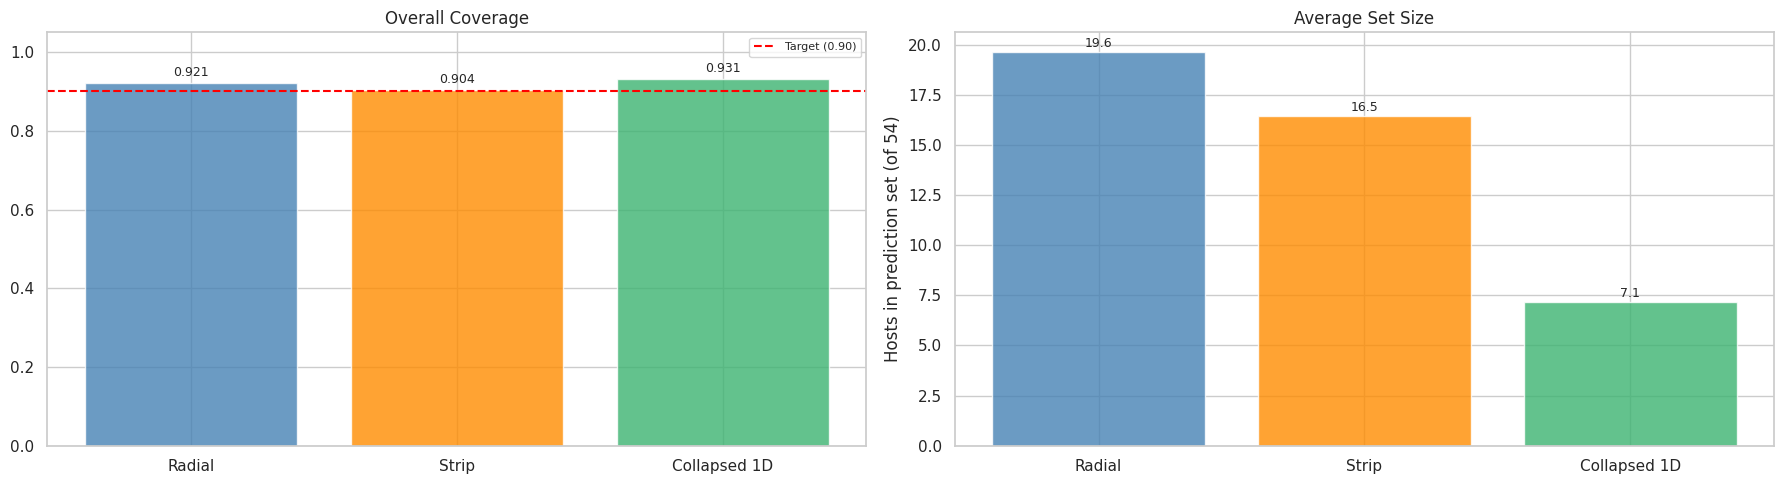

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
colors = ["steelblue", "darkorange", "mediumseagreen"]

# Overall coverage
ax = axes[0]
vals = [m["coverage"] for m in all_metrics]
bars = ax.bar(methods_names, vals, color=colors, alpha=0.8)
ax.axhline(1 - alpha, color="red", linestyle="--", label=f"Target ({1-alpha:.2f})")
ax.set_ylim(0, 1.05)
ax.set_title("Overall Coverage")
ax.legend(fontsize=8)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}", ha="center", va="bottom", fontsize=9)

# Average set size
ax = axes[1]
vals = [m["avg_set_size"] for m in all_metrics]
bars = ax.bar(methods_names, vals, color=colors, alpha=0.8)
ax.set_title("Average Set Size")
ax.set_ylabel(f"Hosts in prediction set (of {len(all_hosts)})")
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1, f"{val:.1f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

#### Per host coverage results

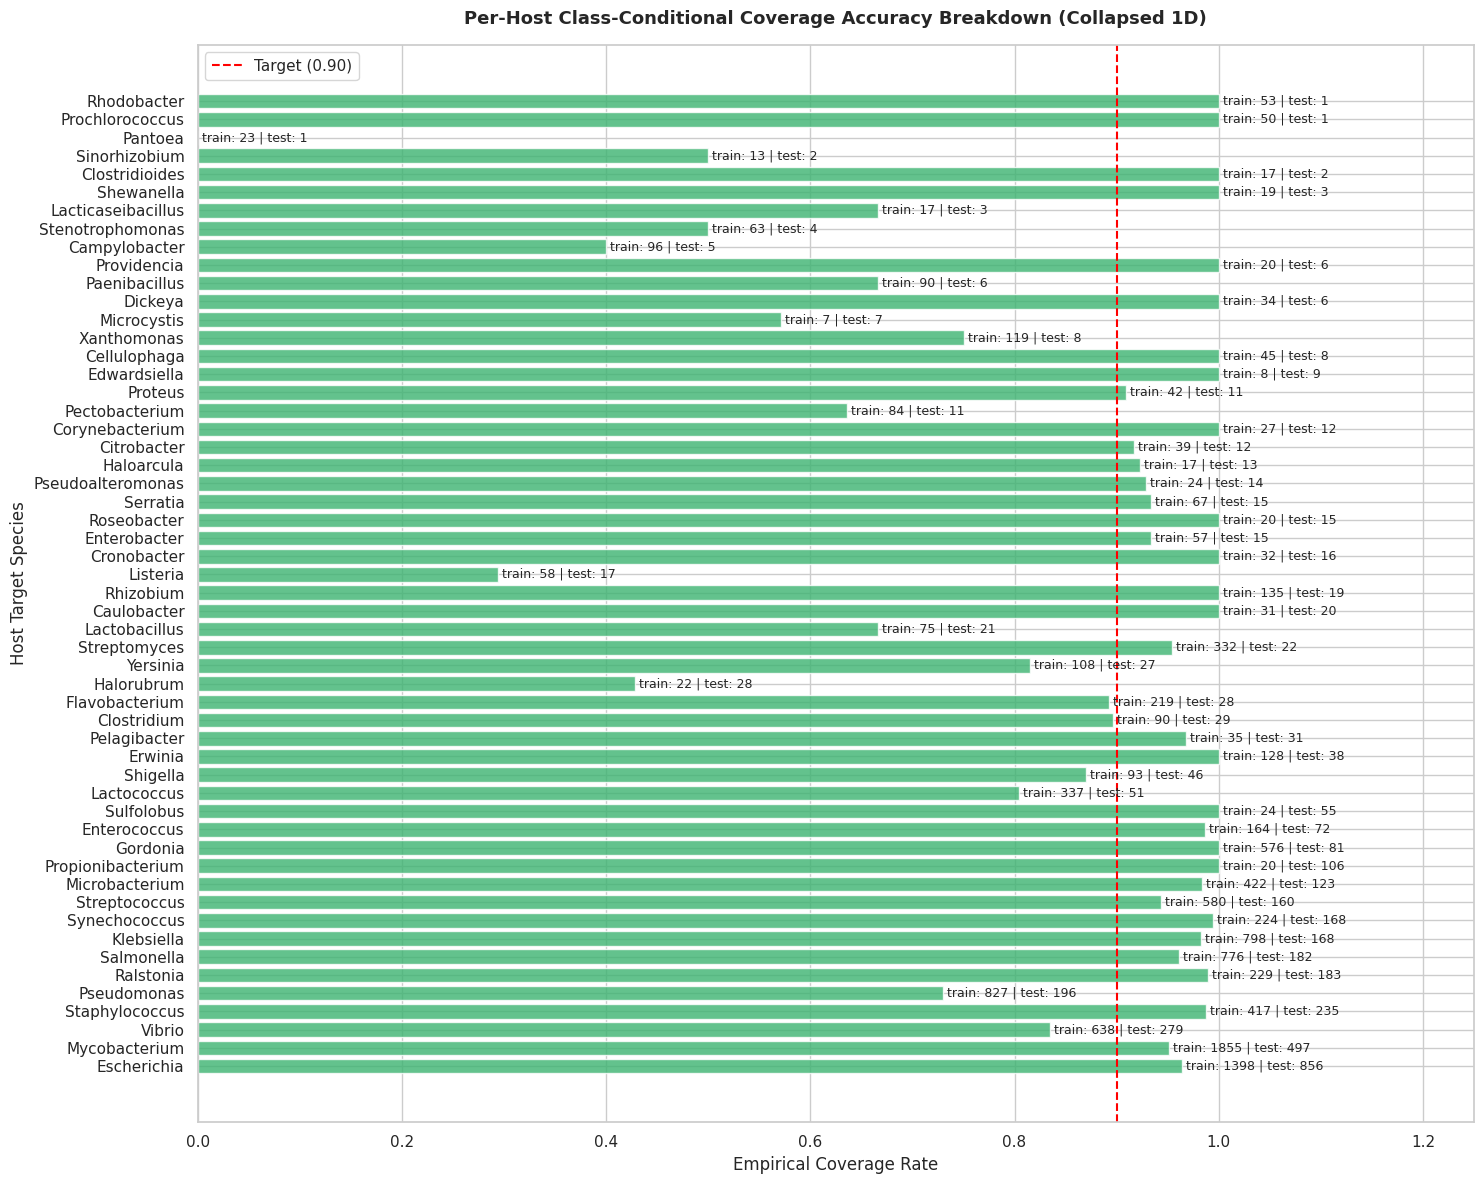

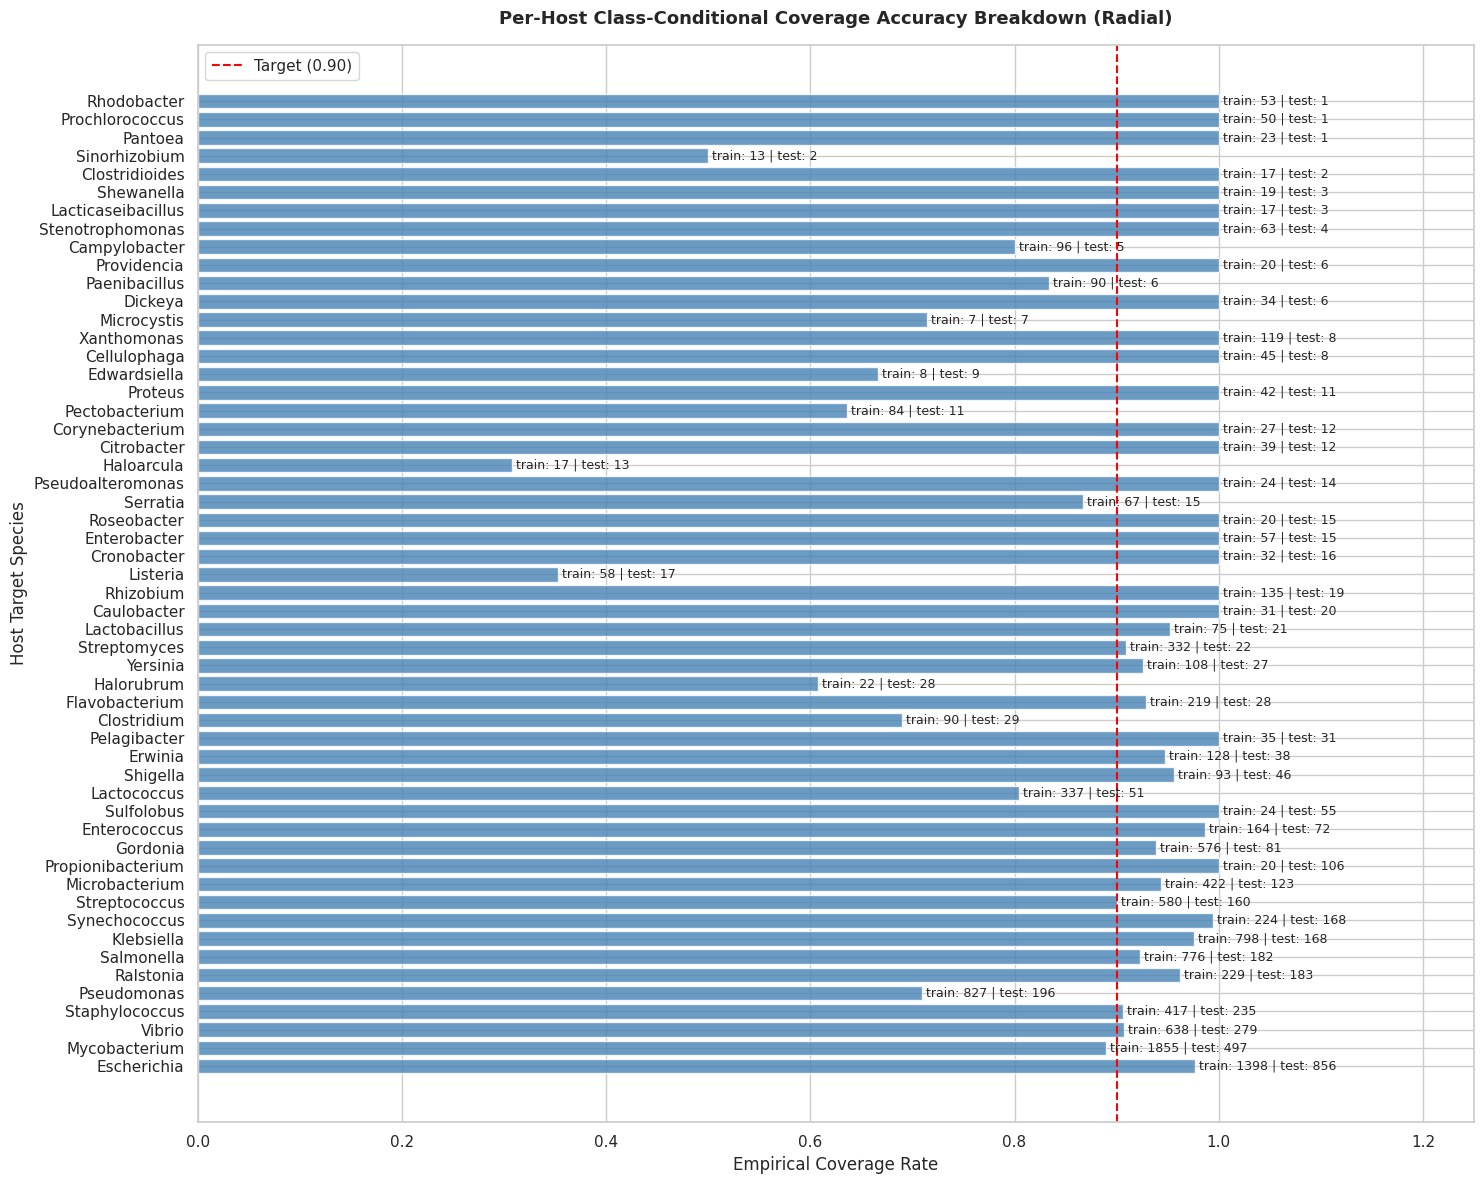

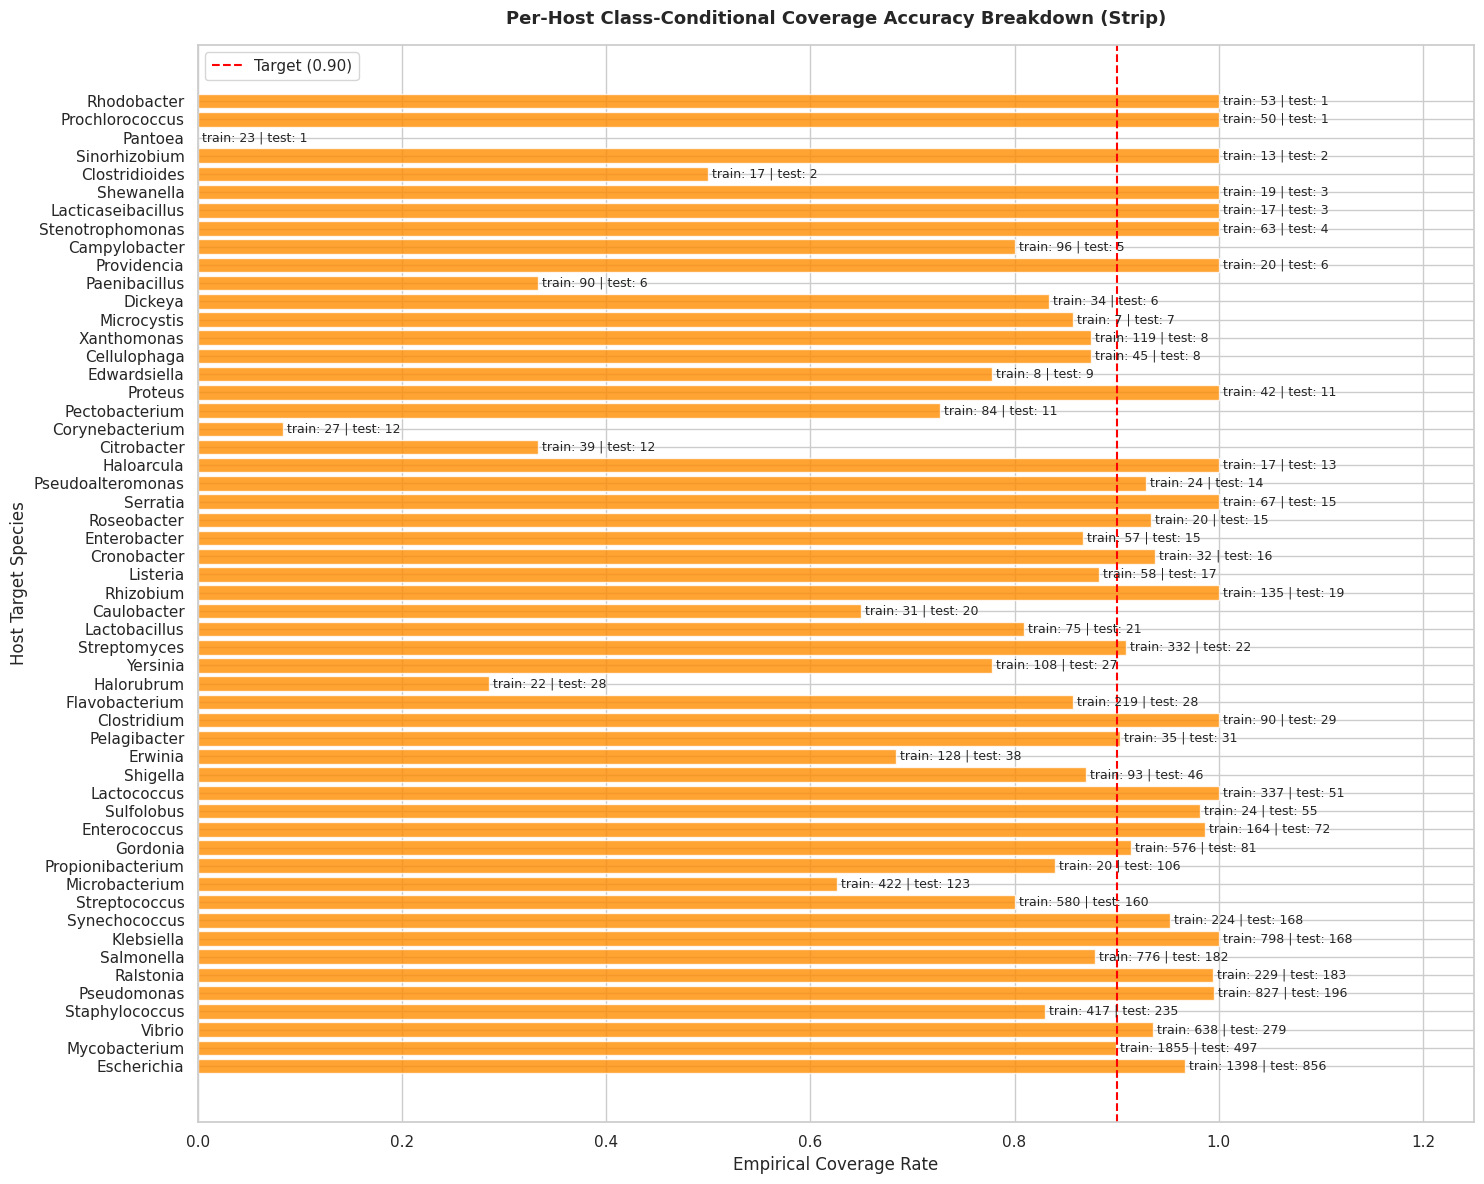

In [22]:
def plot_per_host_coverage(metrics, color, title):
    train_counts = train_df["host"].value_counts().to_dict()
    test_counts = test_df["host"].value_counts().to_dict()
    hosts_sorted = sorted(all_hosts, key=lambda h: test_counts.get(h, 0), reverse=True)

    plt.figure(figsize=(15, 12))
    coverage_vals = [metrics["per_host_coverage"].get(h, 0.0) for h in hosts_sorted]
    bars = plt.barh(hosts_sorted, coverage_vals, color=color, alpha=0.8)
    plt.axvline(1 - alpha, color="red", linestyle="--", label=f"Target ({1-alpha:.2f})")
    for bar, h in zip(bars, hosts_sorted):
        plt.text(x=bar.get_width(), y=bar.get_y() + bar.get_height()/2,
                  s=f" train: {train_counts.get(h,0)} | test: {test_counts.get(h,0)}",
                  va="center", ha="left", fontsize=9)
    plt.xlim(0, 1.25)
    plt.title(f"Per-Host Class-Conditional Coverage Accuracy Breakdown ({title})",
              fontsize=13, fontweight="bold", pad=15)
    plt.xlabel("Empirical Coverage Rate"); plt.ylabel("Host Target Species")
    plt.legend(loc="upper left"); plt.tight_layout(); plt.show()

plot_per_host_coverage(collapsed_metrics, "mediumseagreen", "Collapsed 1D")
plot_per_host_coverage(radial_metrics, "steelblue", "Radial")
plot_per_host_coverage(strip_metrics, "darkorange", "Strip")

#### Set size distribution

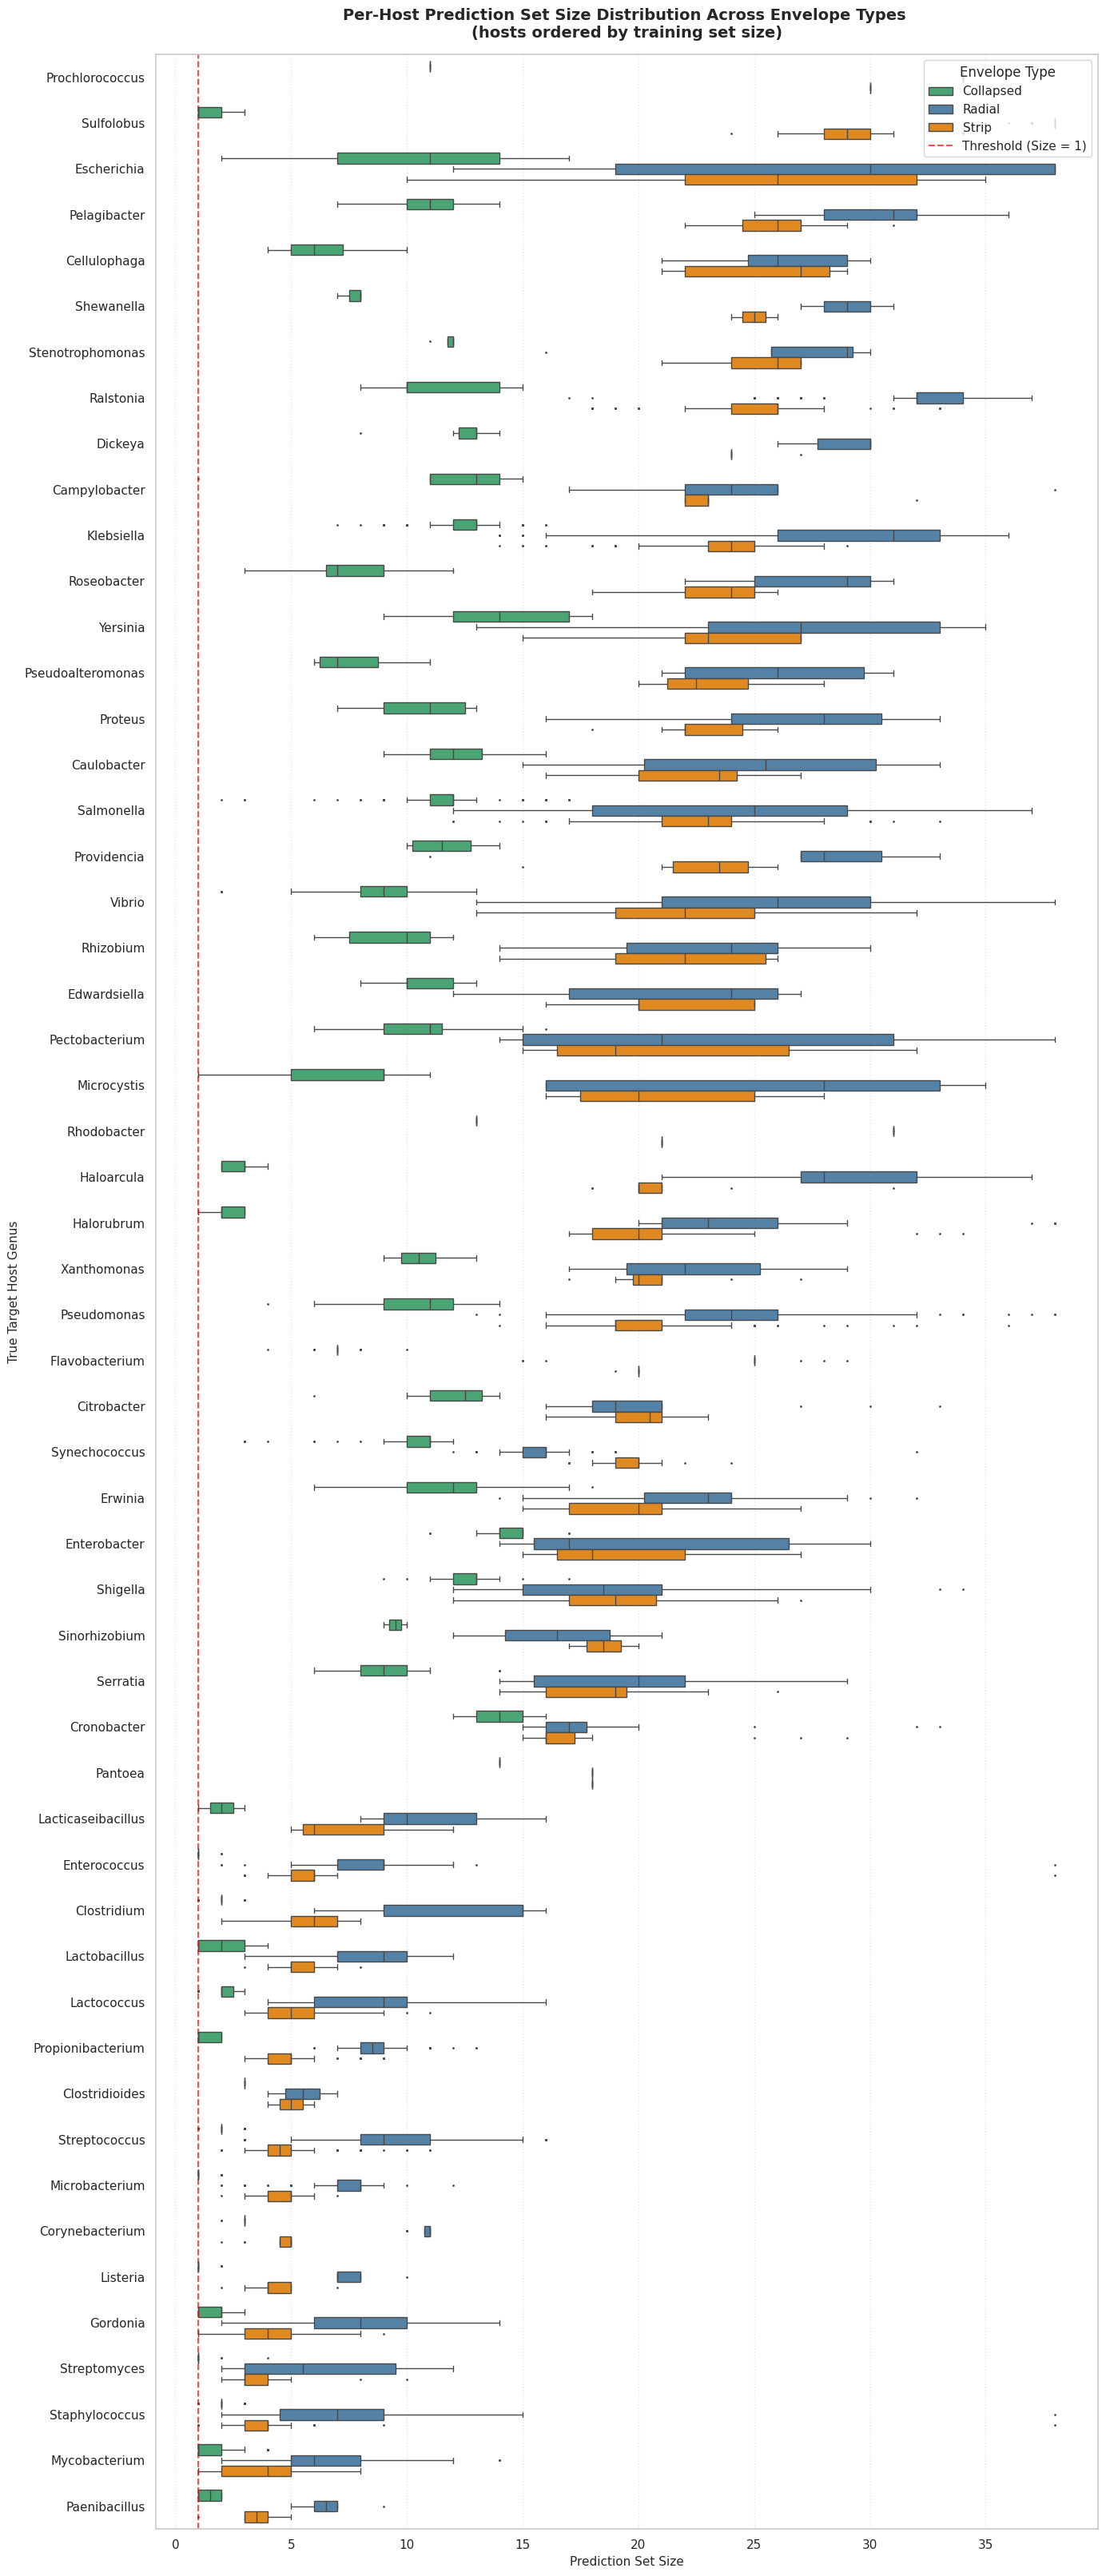

In [23]:
import seaborn as sns
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

methods = ["collapsed", "radial", "strip"]
method_display = {"collapsed": "Collapsed", "radial": "Radial", "strip": "Strip"}
colors = {"collapsed": "mediumseagreen", "radial": "steelblue", "strip": "darkorange"}

# order hosts by training set size, richest first, so the plot doubles as a
# richness-vs-set-size view left to right
hosts_sorted = sorted(all_hosts, key=lambda h: train_df["host"].value_counts().get(h, 0), reverse=True)
positions_base = np.arange(len(hosts_sorted))
box_width = 0.25

# 1. Transform your data into a "long-format" DataFrame
# Seaborn works best when each row is a single observation.
data_list = []
for method in methods:
    for h in hosts_sorted:
        sizes = [len(r["prediction_set"]) 
                 for r, true_h in zip(results_by_method[method], test_labels) if true_h == h]
        for s in (sizes if sizes else [np.nan]):
            data_list.append({"True Host": h, "Set Size": s, "Envelope Type": method_display[method]})

df_all_sets = pd.DataFrame(data_list)

# 2. Sort hosts based on the mean size of one of the types (e.g., 'Strip')
# This keeps the plot organized as in your example.
order_ref = df_all_sets[df_all_sets["Envelope Type"] == "Strip"].groupby("True Host")["Set Size"].mean().sort_values(ascending=False).index

# 3. Create the Plot
plt.figure(figsize=(14, max(8, len(hosts_sorted) * 0.6)))

sns.boxplot(
    data=df_all_sets,
    x="Set Size",
    y="True Host",
    hue="Envelope Type",
    order=order_ref,
    palette=[colors[m] for m in methods], # Maps your custom colors
    fliersize=1,
    width=0.7
)

# 4. Final Polish
plt.axvline(x=1, color="red", linestyle="--", alpha=0.7, label="Threshold (Size = 1)")
plt.title("Per-Host Prediction Set Size Distribution Across Envelope Types \n(hosts ordered by training set size)", fontsize=14, fontweight="bold", pad=15 )
plt.xlabel("Prediction Set Size", fontsize=11)
plt.ylabel("True Target Host Genus", fontsize=11)
plt.grid(axis='x', linestyle=':', alpha=0.5)
plt.legend(title="Envelope Type", loc="upper right")

plt.tight_layout()
plt.show()

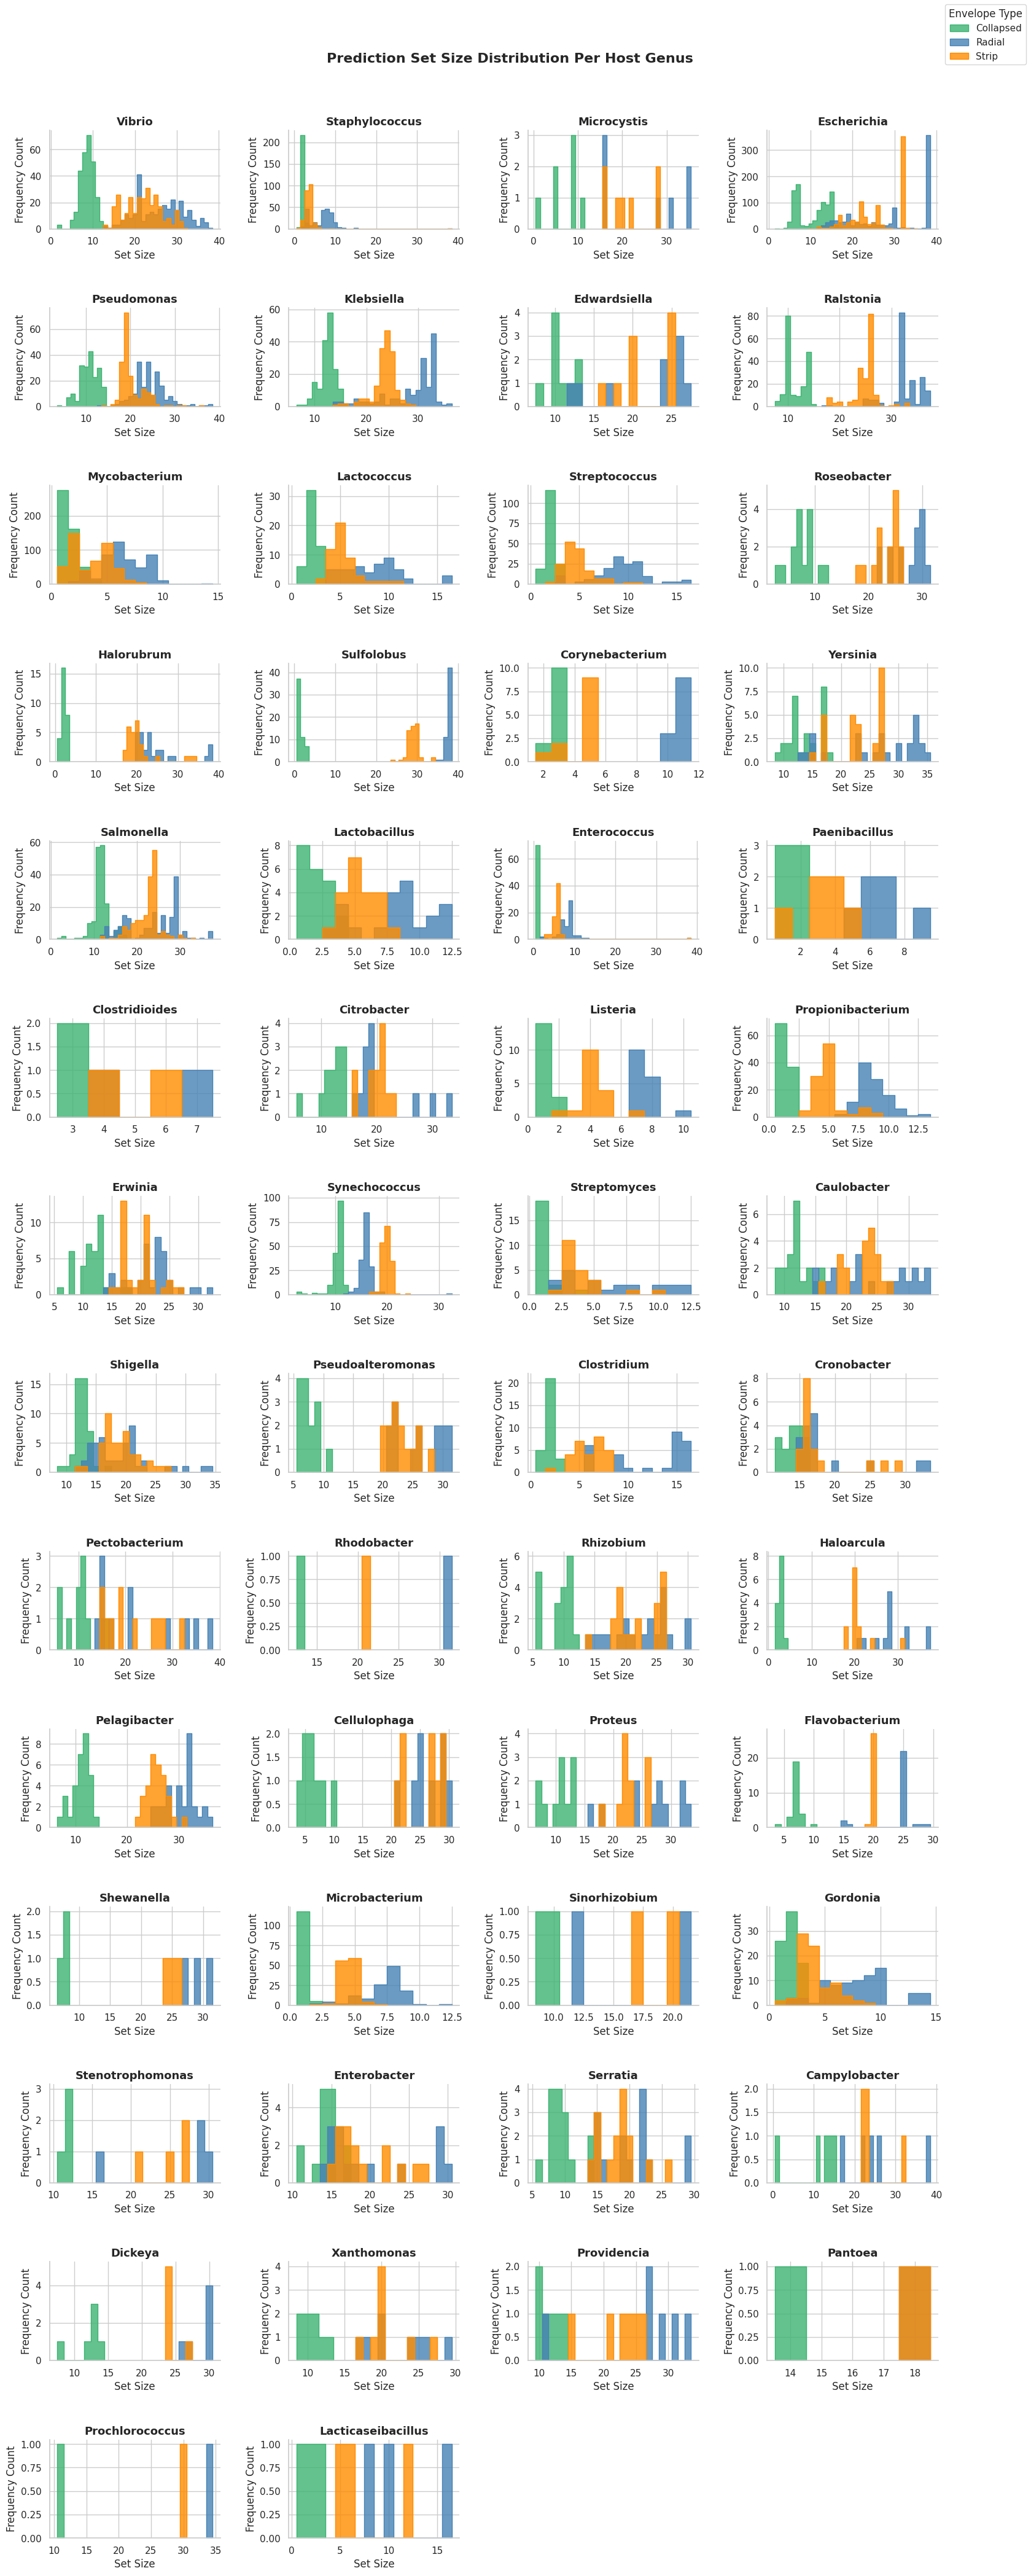

In [24]:
# 1. Gather the set sizes for ALL methods
all_data = []
for method in methods:
    for i, res in enumerate(results_by_method[method]):
        all_data.append({
            "True Host": test_labels[i],
            "Prediction Set Size": len(res["prediction_set"]),
            "Method": method_display[method]
        })

df_all = pd.DataFrame(all_data)

# 2. Define the palette mapping
palette_mapping = {
    "Collapsed": "mediumseagreen", 
    "Radial": "steelblue", 
    "Strip": "darkorange"
}

# 3. Create the FacetGrid with the palette argument
g = sns.FacetGrid(
    df_all, 
    col="True Host", 
    hue="Method", 
    col_wrap=4, 
    sharex=False, 
    sharey=False, 
    height=3, 
    aspect=1.3,
    palette=palette_mapping  # Custom colors applied here
)

g.map_dataframe(sns.histplot, x="Prediction Set Size", discrete=True, element="step", alpha=0.8)

for ax in g.axes.flat:
    ax.set_xlabel("Set Size")
    ax.tick_params(labelbottom=True)
    ax.set_ylabel("Frequency Count")

g.add_legend(title="Envelope Type", loc="upper right", frameon=True)
g.set_titles("{col_name}", fontweight="bold", size=13)
plt.subplots_adjust(top=0.95, hspace=0.8, wspace=0.4)
plt.suptitle("Prediction Set Size Distribution Per Host Genus", fontsize=16, fontweight="bold")
plt.show()

### Heat Maps

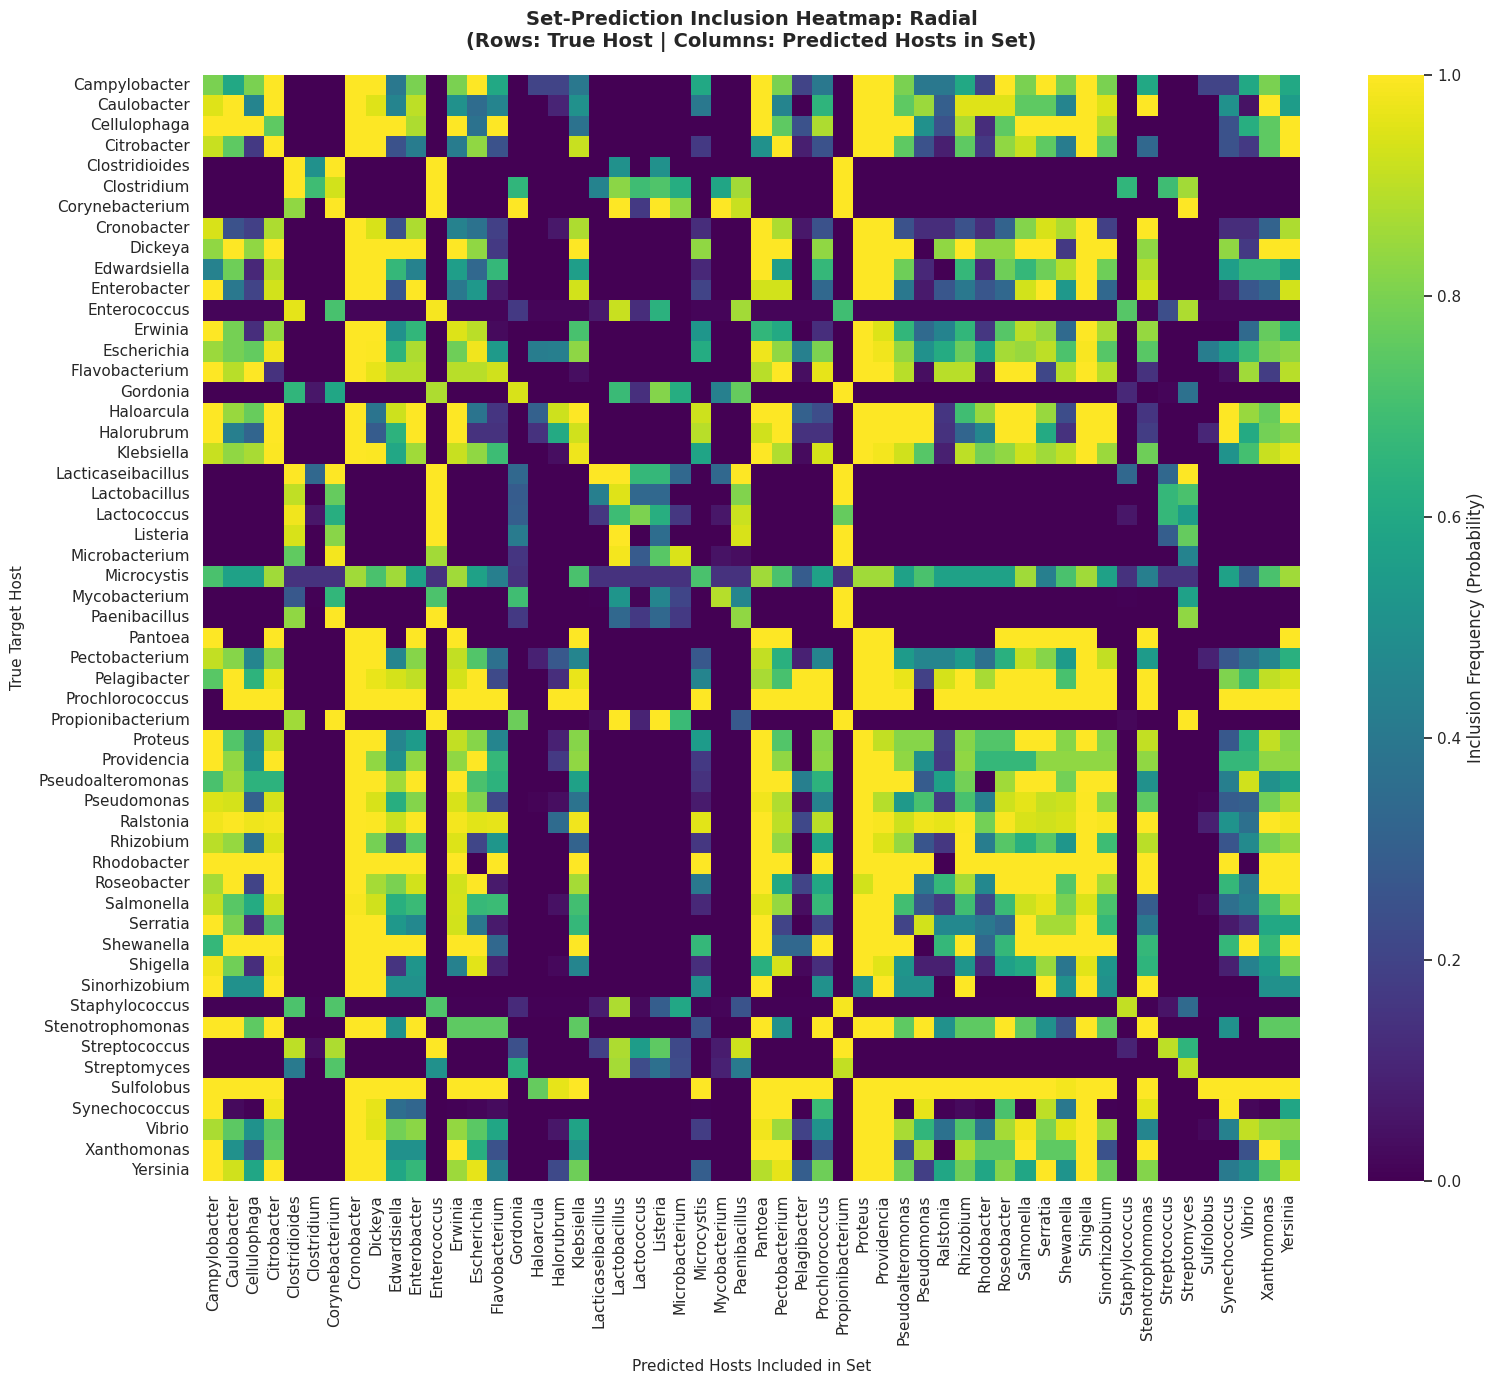

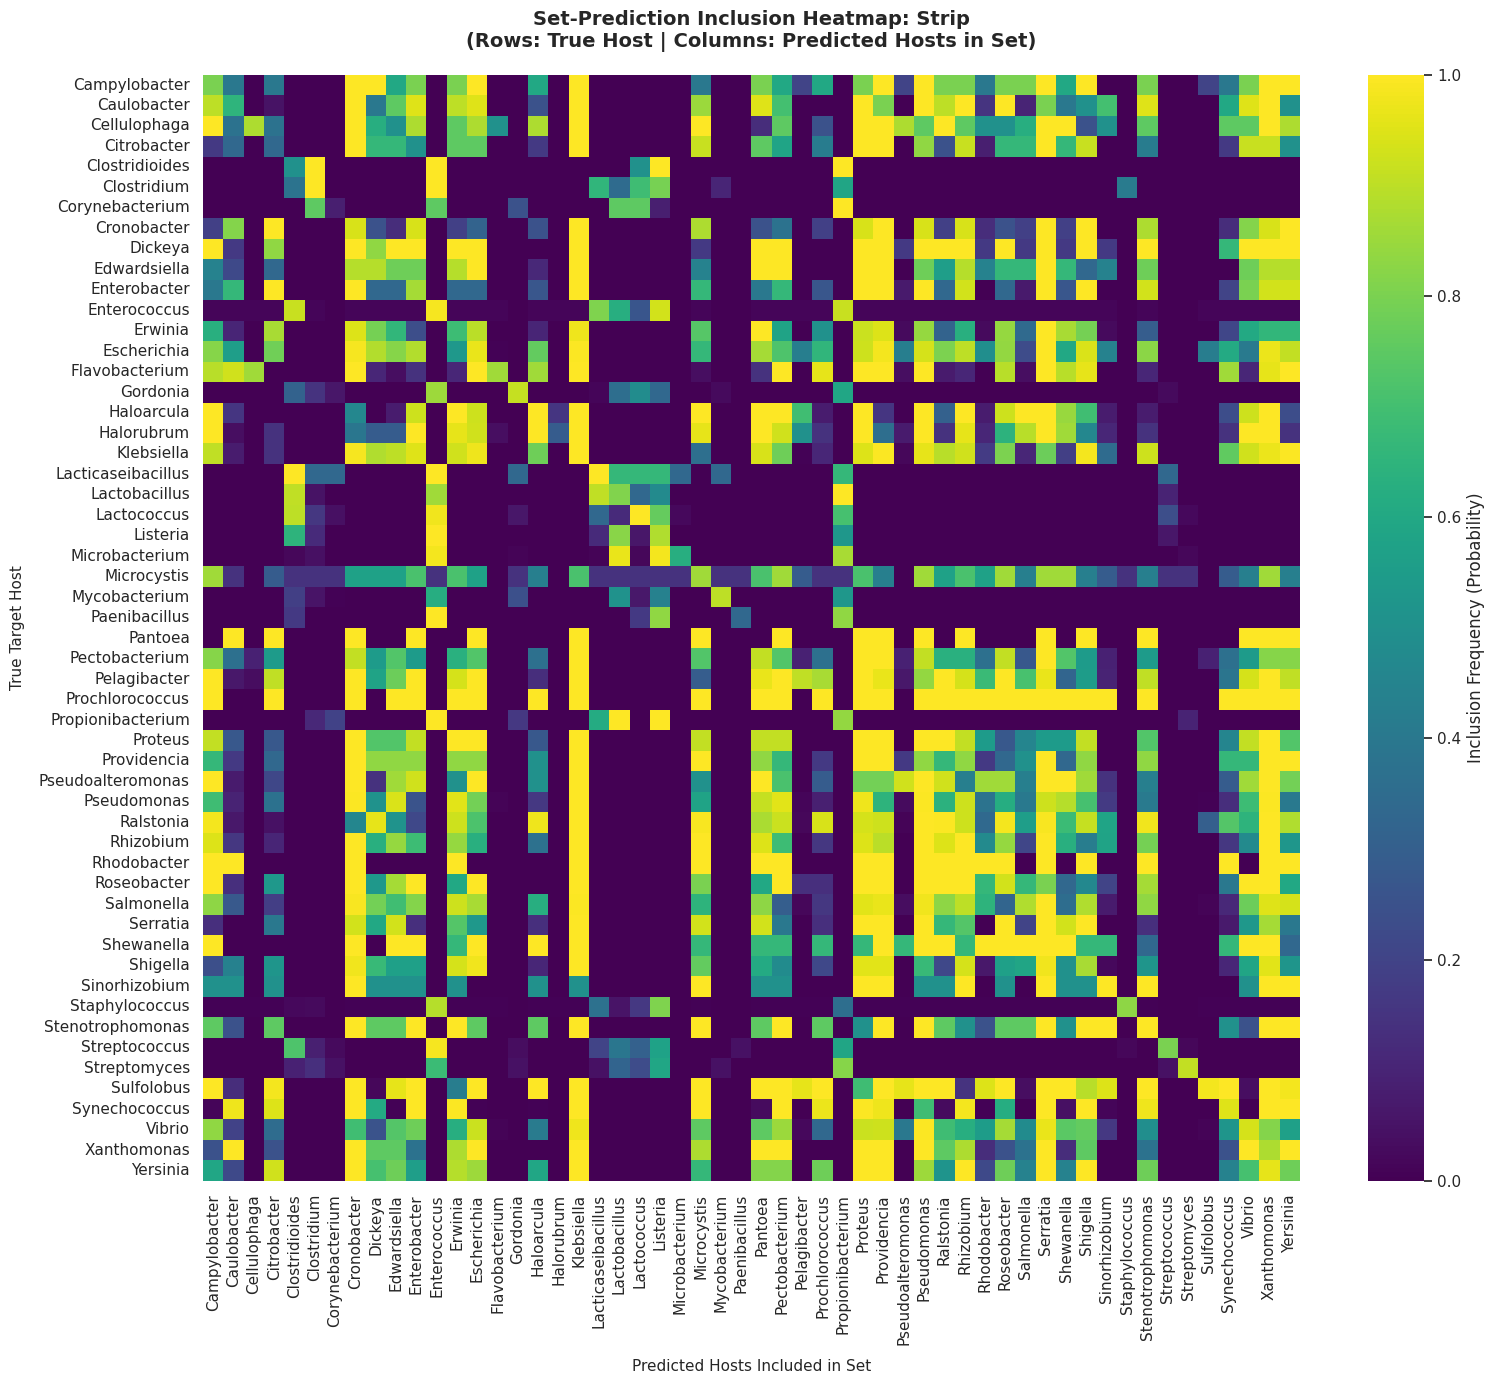

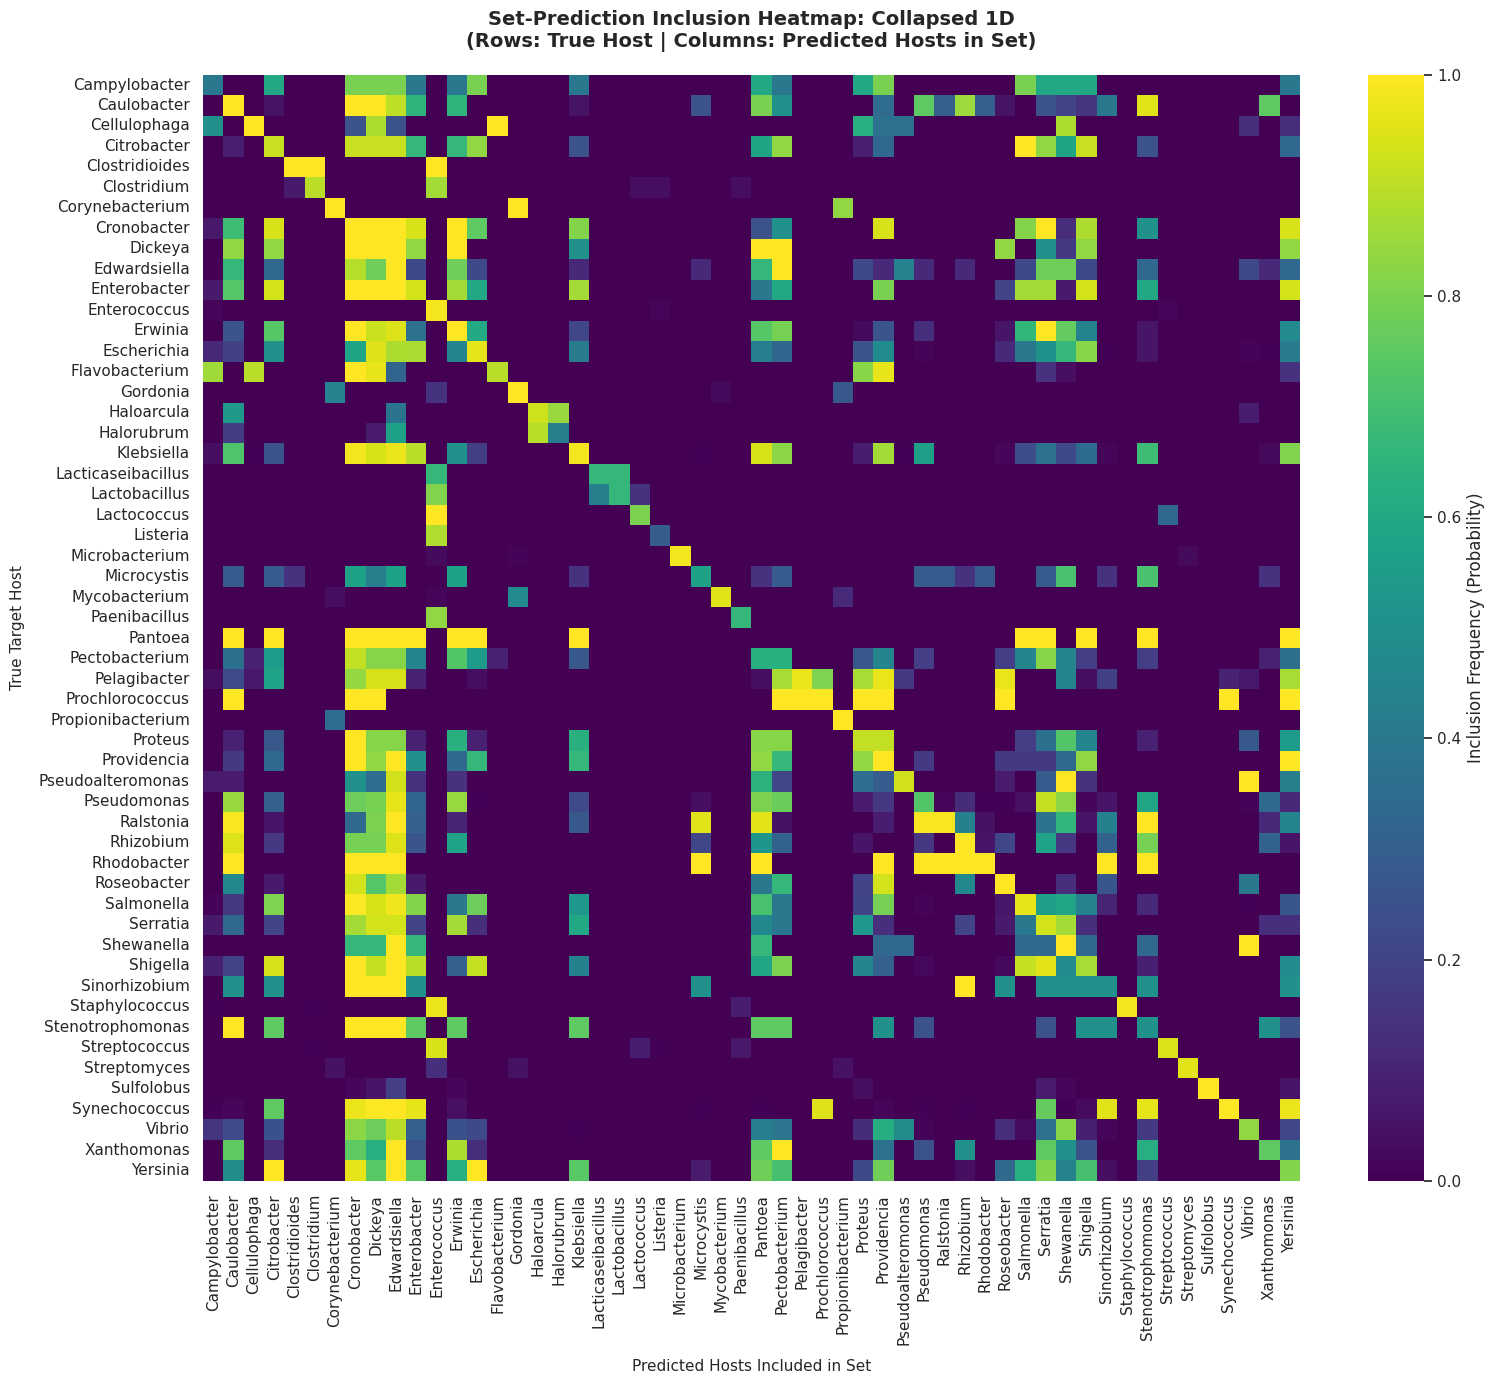

In [25]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# AFTER — never rebind the globals; use local names for this cell only
unique_hosts = sorted(list(set(test_labels)))
valid_host_set = set(unique_hosts)   # was: host_col_map = set(all_hosts)
host_to_idx = {host: idx for idx, host in enumerate(unique_hosts)}

# Extracting from 'results_by_method' matching the keys from your execution loop
methods_dict = {
    "Radial": results_by_method["radial"],
    "Strip": results_by_method["strip"],
    "Collapsed 1D": results_by_method["collapsed"]
}

# Create the supporting df_set_sizes DataFrame used for the row normalization sums
df_set_sizes = pd.DataFrame({"True Host": test_labels})


# --- 2. GENERATE THE HEATMAPS ---
for method_name, results_list in methods_dict.items():
    # Initialize a matrix of zeros: shape (True Hosts, Predicted Hosts)
    matrix_counts = np.zeros((len(unique_hosts), len(unique_hosts)))   # was len(all_hosts)
    
    for idx, true_lbl in enumerate(test_labels):
        row_idx = host_to_idx[true_lbl]
        pred_set = results_list[idx]["prediction_set"]
        
        for pred_host in pred_set:
            if pred_host in valid_host_set:                                     # was host_col_map
                col_idx = host_to_idx[pred_host]                                # was all_hosts.index(pred_host) — also O(n), this is a free speed fix
                matrix_counts[row_idx, col_idx] += 1
                
    # Calculate total true samples per host to normalize into inclusion probabilities
    row_sums = df_set_sizes.groupby("True Host").size().reindex(unique_hosts).values[:, None]
    
    # Divide counts by sums safely (avoiding division by zero)
    df_heatmap = pd.DataFrame(matrix_counts / np.where(row_sums == 0, 1, row_sums),
                           index=unique_hosts, columns=unique_hosts)   # was columns=all_hosts
    # Plotting configuration
    plt.figure(figsize=(16, 14))
    sns.heatmap(
        df_heatmap, 
        cmap="viridis", 
        vmin=0.0, 
        vmax=1.0, 
        cbar_kws={'label': 'Inclusion Frequency (Probability)'}, 
        xticklabels=True, 
        yticklabels=True
    )
    plt.title(f"Set-Prediction Inclusion Heatmap: {method_name}\n(Rows: True Host | Columns: Predicted Hosts in Set)", fontsize=14, fontweight="bold", pad=20)
    plt.xlabel("Predicted Hosts Included in Set", fontsize=11, labelpad=10)
    plt.ylabel("True Target Host", fontsize=11, labelpad=10)
    plt.tight_layout()
    plt.show()

## Testing

#### filtering out hosts with low sample hosts

In [26]:
print("\n" + "="*75)
print(" FILTERING OUT LOW-DATA HOSTS")
print("="*75)

# Task 2: Kick out hosts with lower data baseline counts in the train split
min_train_phages_required = 150
train_host_counts = pd.Series(train_labels).value_counts()
robust_hosts = train_host_counts[train_host_counts >= min_train_phages_required].index.tolist()

print(f"Original unique hosts evaluated: {len(all_hosts)}")
print(f"Hosts selected (with >= {min_train_phages_required} training samples): {len(robust_hosts)}")
print(f"Remaining hosts to evaluate: {sorted(robust_hosts)}")


# report robust_strip_metrics_M5 here
print("\n--- OLD STRIP PERFORMANCE ---")
print(f"Old Strip Coverage (M={number_of_bins}): {strip_metrics['coverage']:.3f}")
print(f"Old Strip Average Set Size: {strip_metrics['avg_set_size']:.2f}")


# Task 3: Modulate the number of bins to M=5 for the hosts group
modulated_M = 5
print(f"\nRe-building Strip envelopes for hosts using bins (M={modulated_M})...")


host_col_map = {h: [i for i, c in enumerate(score_cols) if c.split("_")[0] == h] for h in all_hosts}

robust_per_host_envs_s = {}
for h in robust_hosts:
    h_idx = host_col_map[h]
    mask_h = train_labels == h
    n_h = mask_h.sum()
    train_nc_h = train_nc[mask_h][:, h_idx]
    
    # Mirroring split validation structure from build_per_host_envelopes
    rng = np.random.default_rng(42)
    idx = rng.permutation(n_h)
    half = n_h // 2
    S1 = train_nc_h[idx[:half]]
    S2 = train_nc_h[idx[half:]]
    labels_S2 = np.array([h] * len(S2))
    
    # Custom calibration with dynamic custom parameters
    env = strip_build_envelope(S1, S2, labels_S2, [h], alpha, M=modulated_M)
    robust_per_host_envs_s[h] = {"envelope": env, "col_indices": h_idx}

# Evaluate the filtered set on the test set sequence loop
robust_strip_results = []
robust_test_labels = []

for i, acc in enumerate(test_df.index):
    true_host = test_labels[i]
    if true_host not in robust_hosts:
        continue # Skip test sequences that don't belong to our filtered robust hosts
        
    allowed = candidate_hosts_for(acc)
    # Restrict tracking targets to allowed lists that exist inside the robust envelopes structure
    active = {h: robust_per_host_envs_s[h] for h in allowed if h in robust_per_host_envs_s}
    if not active:
        active = robust_per_host_envs_s
        
    robust_strip_results.append(predict_host(test_raw[i:i+1], active, list(active.keys()))[0])
    robust_test_labels.append(true_host)

# Calculate metrics configuration updates
robust_strip_metrics = evaluate_multiclass(robust_strip_results, np.array(robust_test_labels), robust_hosts, alpha)

print("\n--- NEW STRIP PERFORMANCE ---")
print(f"New Strip Coverage (M={modulated_M}): {robust_strip_metrics['coverage']:.3f}")
print(f"New Strip Average Set Size: {robust_strip_metrics['avg_set_size']:.2f}")


 FILTERING OUT LOW-DATA HOSTS
Original unique hosts evaluated: 54
Hosts selected (with >= 150 training samples): 16
Remaining hosts to evaluate: ['Enterococcus', 'Escherichia', 'Flavobacterium', 'Gordonia', 'Klebsiella', 'Lactococcus', 'Microbacterium', 'Mycobacterium', 'Pseudomonas', 'Ralstonia', 'Salmonella', 'Staphylococcus', 'Streptococcus', 'Streptomyces', 'Synechococcus', 'Vibrio']

--- OLD STRIP PERFORMANCE ---
Old Strip Coverage (M=5): 0.904
Old Strip Average Set Size: 16.45

Re-building Strip envelopes for hosts using bins (M=5)...

--- NEW STRIP PERFORMANCE ---
New Strip Coverage (M=5): 0.940
New Strip Average Set Size: 3.62


#### 2D envelopes

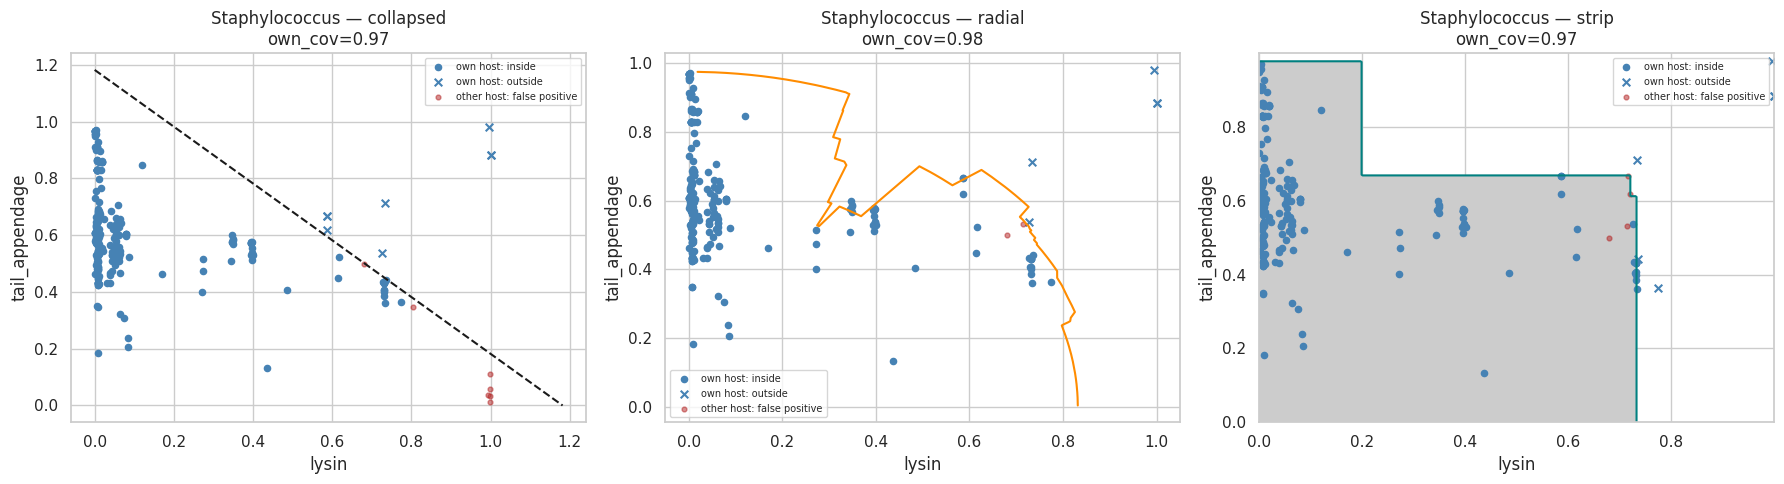

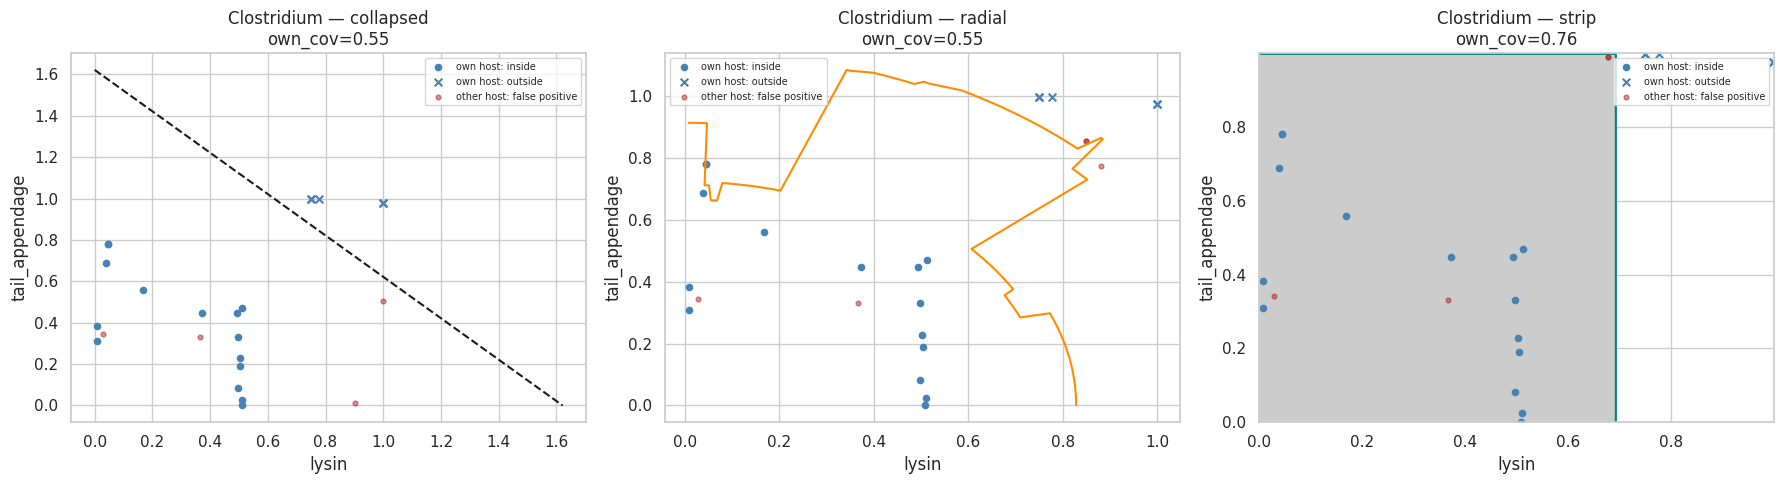

In [40]:
def get_2d_scores(df, host, func_x, func_y):
    return df[[f"{host}_{func_x}", f"{host}_{func_y}"]]

def build_2d_envelope(train_df, host, func_x, func_y, alpha, method, seed=42, M=5):
    raw = get_2d_scores(train_df[train_df["host"] == host], host, func_x, func_y).values
    nc = raw_to_nc(raw)
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(nc))
    S1, S2 = nc[idx[:len(nc)//2]], nc[idx[len(nc)//2:]]
    labels_S2 = np.array([host] * len(S2))
    if method == "collapsed":
        return collapsed_build_envelope(S1, S2, labels_S2, [host], alpha)
    elif method == "radial":
        return radial_build_envelope(S1, S2, labels_S2, [host], alpha, rng=rng)   # add rng=rng
    else:
        return strip_build_envelope(S1, S2, labels_S2, [host], alpha, M=M)

def plot_diagnostic_host_envelope_2d(host_name, func_x, func_y):
    cx, cy = f"{host_name}_{func_x}", f"{host_name}_{func_y}"
    if cx not in score_cols or cy not in score_cols:
        print(f"{host_name}: missing {func_x}/{func_y} columns")
        return
    own_raw = get_2d_scores(test_df[test_df["host"] == host_name], host_name, func_x, func_y).values
    other_raw = get_2d_scores(test_df[test_df["host"] != host_name], host_name, func_x, func_y).values
    own_nc, other_nc = raw_to_nc(own_raw), raw_to_nc(other_raw)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, method in zip(axes, ["collapsed", "radial", "strip"]):
        env = build_2d_envelope(train_df, host_name, func_x, func_y, alpha, method)
        own_in = is_in_region(own_nc, env) if len(own_nc) else np.array([])
        other_in = is_in_region(other_nc, env) if len(other_nc) else np.array([])
        if len(own_nc):
            ax.scatter(own_nc[own_in, 0], own_nc[own_in, 1], c="steelblue", s=20, label="own host: inside")
            ax.scatter(own_nc[~own_in, 0], own_nc[~own_in, 1], c="steelblue", marker="x", s=30, label="own host: outside")
        if len(other_nc):
            ax.scatter(other_nc[other_in, 0], other_nc[other_in, 1], c="firebrick", s=12, alpha=0.5, label="other host: false positive")
        if method == "collapsed":
            t = env["q_tilde"] * env["t_hat"]
            ax.plot([0, 2*t], [2*t, 0], "k--", lw=1.5)
        elif method == "radial":
            b = env["U"] * (env["q_tilde"] * env["t_hat"])[:, None]
            order = np.argsort(np.arctan2(b[:, 1], b[:, 0]))
            ax.plot(b[order, 0], b[order, 1], c="darkorange", lw=1.5)
        else:
            # 1. Safely extract max values, defaulting to 1.0 if empty or NaN
            def get_safe_max(data, default=1.0):
                if len(data) == 0: return default
                finite_data = data[np.isfinite(data)]
                return finite_data.max() if len(finite_data) > 0 else default

            x_max = max(get_safe_max(own_nc[:, 0]), get_safe_max(other_nc[:, 0]))
            y_max = max(get_safe_max(own_nc[:, 1]), get_safe_max(other_nc[:, 1]))
            
            # 2. Create the grid
            gx, gy = np.meshgrid(np.linspace(0, x_max, 250), np.linspace(0, y_max, 250))
            grid_nc = np.column_stack([gx.ravel(), gy.ravel()])
            
            # 3. Compute and sanitize the mask
            mask_raw = strip_is_in_region(grid_nc, env)
            grid_in = np.nan_to_num(mask_raw.astype(float)).reshape(gx.shape)
            
            # 4. Use imshow instead of pcolormesh
            # imshow is much more forgiving with grid data and easier to align
            ax.imshow(grid_in, origin='lower', extent=[0, x_max, 0, y_max], 
                      cmap='Greys', alpha=0.2, vmin=0, vmax=1, aspect='auto')
            
            # 5. Draw the contour
            ax.contour(gx, gy, grid_in, levels=[0.5], colors="teal", linewidths=1.5)

        
        own_cov = own_in.mean() if len(own_nc) else float("nan")
        ax.set_title(f"{host_name} — {method}\nown_cov={own_cov:.2f}")
        ax.set_xlabel(f"{func_x}"); ax.set_ylabel(f"{func_y}")
        ax.legend(fontsize=7)
    plt.tight_layout(); plt.show()

plot_diagnostic_host_envelope_2d("Staphylococcus", "lysin", "tail_appendage")
plot_diagnostic_host_envelope_2d("Clostridium", "lysin", "tail_appendage")

### Checks

#### checking if the calibration even self covers 
   - isolate one host
   - build strip envelope
   - check coverage on S2
   - if coverage is not 0.9 then the bug is in "strip_shape_discovery" or "quantile_for_class"
   - else issue maybe in how the test data is fed

In [28]:
host = "Escherichia"  # pick a big one so sample noise isn't the excuse
h_idx = host_col_map[host]
mask_h = train_labels == host
train_nc_h = train_nc[mask_h][:, h_idx]

rng = np.random.default_rng(42)
n_h = train_nc_h.shape[0]
idx = rng.permutation(n_h)
half = n_h // 2
S1 = train_nc_h[idx[:half]]
S2 = train_nc_h[idx[half:]]
labels_S2 = np.array([host] * len(S2))

env = strip_build_envelope(S1, S2, labels_S2, [host], alpha)
tau2 = strip_tau_scores(S2, env["bin_edges"], env["limits"], env["marginal_quantiles"])
print("Self-coverage on S2 (must be ~0.9):", np.mean(tau2 <= env["t_hat"]))

# Now check against this host's actual test-fold points
mask_test_h = test_labels == host
test_nc_h = test_nc[mask_test_h][:, h_idx]
tau_test = strip_tau_scores(test_nc_h, env["bin_edges"], env["limits"], env["marginal_quantiles"])
print("Test-fold coverage (target ~0.9):", np.mean(tau_test <= env["t_hat"]))

Self-coverage on S2 (must be ~0.9): 0.994277539341917
Test-fold coverage (target ~0.9): 0.9953271028037384


#### Are the scors actually bounded in [0,1]?

In [29]:
print("train_nc min/max:", np.nanmin(train_nc), np.nanmax(train_nc))
print("test_nc min/max:", np.nanmin(test_nc), np.nanmax(test_nc))
print("Any negative NC?", np.nansum(train_nc < 0), np.nansum(test_nc < 0))
print("Any NC > 1?", np.nansum(train_nc > 1), np.nansum(test_nc > 1))

train_nc min/max: 1.3132828158290977e-12 0.9999998999999901
test_nc min/max: 2.662170484057924e-11 0.9999998999999901
Any negative NC? 0 0
Any NC > 1? 0 0


#### degenerate columns (zero variance in S1)

In [30]:
# Check if the host exists and how many samples it has
h_idx = host_col_map[host]
train_nc_h = train_nc[train_labels == host][:, h_idx]
n_h = train_nc_h.shape[0]

print(f"Debug: Found {n_h} samples for host '{host}'")

if n_h > 0:
    rng = np.random.default_rng(42)
    idx = rng.permutation(n_h)
    S1 = train_nc_h[idx[:n_h//2]]
    print(f"Debug: S1 shape is {S1.shape}")
    
    if S1.shape[0] == 0:
        print("Warning: S1 is empty because n_h was less than 2.")
else:
    print(f"Error: No data found for host '{host}'. Check your labels and map.")

Debug: Found 1398 samples for host 'Escherichia'
Debug: S1 shape is (699, 40)


In [31]:
h_idx = host_col_map[host]
train_nc_h = train_nc[train_labels == host][:, h_idx]
rng = np.random.default_rng(42)
n_h = train_nc_h.shape[0]
idx = rng.permutation(n_h)
S1 = train_nc_h[idx[:n_h//2]]

for j in range(S1.shape[1]):
    col = S1[:, j]
    col_valid = col[~np.isnan(col)]
    if len(col_valid) == 0:
        print(f"col {j}: ALL NaN in S1")
    elif np.nanmin(col) == np.nanmax(col):
        print(f"col {j}: constant value {np.nanmin(col)} — degenerate bin_edges")

#### per-host breakdown to see if failure is uniform or concentrated

In [32]:
per_host_strip_cov = {}
for h in all_hosts:
    h_idx = host_col_map[h]
    if len(h_idx) == 0:
        continue
    mask_h = train_labels == h
    n_h = mask_h.sum()
    if n_h < 6:
        continue
    train_nc_h = train_nc[mask_h][:, h_idx]
    rng = np.random.default_rng(42)
    idx = rng.permutation(n_h)
    half = n_h // 2
    S1 = train_nc_h[idx[:half]]
    S2 = train_nc_h[idx[half:]]
    labels_S2 = np.array([h] * len(S2))

    env = strip_build_envelope(S1, S2, labels_S2, [h], alpha)
    tau2 = strip_tau_scores(S2, env["bin_edges"], env["limits"], env["marginal_quantiles"])
    self_cov = np.mean(tau2 <= env["t_hat"])

    mask_test_h = test_labels == h
    if mask_test_h.sum() == 0:
        continue
    test_nc_h = test_nc[mask_test_h][:, h_idx]
    tau_test = strip_tau_scores(test_nc_h, env["bin_edges"], env["limits"], env["marginal_quantiles"])
    test_cov = np.mean(tau_test <= env["t_hat"])

    per_host_strip_cov[h] = (n_h, self_cov, test_cov)

import pandas as pd
df_diag = pd.DataFrame(per_host_strip_cov, index=["n_h", "self_cov", "test_cov"]).T
df_diag = df_diag.sort_values("test_cov")
print(df_diag.to_string())

                       n_h  self_cov  test_cov
Corynebacterium       27.0  1.000000  0.000000
Clostridioides        17.0  1.000000  0.000000
Pantoea               23.0  1.000000  0.000000
Haloarcula            17.0  1.000000  0.384615
Ralstonia            229.0  0.956522  0.469945
Lactobacillus         75.0  0.947368  0.571429
Halorubrum            22.0  1.000000  0.750000
Edwardsiella           8.0  1.000000  0.777778
Yersinia             108.0  0.925926  0.777778
Campylobacter         96.0  1.000000  0.800000
Flavobacterium       219.0  0.909091  0.821429
Listeria              58.0  0.931034  0.823529
Paenibacillus         90.0  0.977778  0.833333
Providencia           20.0  1.000000  0.833333
Dickeya               34.0  1.000000  0.833333
Gordonia             576.0  0.975694  0.876543
Sulfolobus            24.0  1.000000  0.890909
Salmonella           776.0  0.904639  0.906593
Streptomyces         332.0  0.915663  0.909091
Pectobacterium        84.0  1.000000  0.909091
Klebsiella   

#### Fallback count

In [33]:
fallback_counts = {}
for h in all_hosts:
    h_idx = host_col_map[h]
    if len(h_idx) == 0:
        continue
    mask_h = train_labels == h
    n_h = mask_h.sum()
    if n_h < 6:
        continue
    train_nc_h = train_nc[mask_h][:, h_idx]
    rng = np.random.default_rng(42)
    idx = rng.permutation(n_h)
    S1 = train_nc_h[idx[:n_h // 2]]
    N1, K = S1.shape

    bin_edges = np.array([
        np.linspace(np.nanmin(S1[:, j]), np.nanmax(S1[:, j]), number_of_bins + 1)
        for j in range(K)
    ])
    total_pairs = 0
    fallback_pairs = 0
    for j in range(K):
        for m in range(number_of_bins):
            lo, hi = bin_edges[j, m], bin_edges[j, m + 1]
            in_strip = (~np.isnan(S1[:, j])) & (S1[:, j] >= lo) & (S1[:, j] < hi)
            for i in range(K):
                if i == j:
                    continue
                total_pairs += 1
                src_mask = in_strip & (~np.isnan(S1[:, i]))
                if src_mask.sum() < 3:
                    fallback_pairs += 1
    fallback_counts[h] = (n_h, K, fallback_pairs / total_pairs)

import pandas as pd
df_fb = pd.DataFrame(fallback_counts, index=["n_h", "K", "fallback_rate"]).T
print(df_fb.sort_values("fallback_rate", ascending=False).to_string())
print("\nOverall mean fallback rate:", df_fb["fallback_rate"].mean())

                       n_h     K  fallback_rate
Edwardsiella           8.0  39.0       1.000000
Microcystis            7.0  38.0       1.000000
Sinorhizobium         13.0  38.0       0.988620
Haloarcula            17.0  30.0       0.985747
Halorubrum            22.0  31.0       0.949677
Clostridioides        17.0  36.0       0.937778
Shewanella            19.0  40.0       0.933205
Lacticaseibacillus    17.0  30.0       0.926897
Pseudoalteromonas     24.0  38.0       0.912376
Propionibacterium     20.0  31.0       0.900860
Roseobacter           20.0  37.0       0.895045
Providencia           20.0  40.0       0.887692
Sulfolobus            24.0  26.0       0.878154
Pantoea               23.0  40.0       0.860769
Pelagibacter          35.0  37.0       0.836186
Corynebacterium       27.0  33.0       0.781250
Dickeya               34.0  37.0       0.774474
Cronobacter           32.0  40.0       0.766026
Caulobacter           31.0  40.0       0.736410
Proteus               42.0  40.0       0

### Using only selected features

In [34]:
def select_top_features(train_nc, train_labels, host, h_idx, k_select=5):
    """Pick the k_select columns (of this host's own scoring functions) that
    best separate this host's true phages from everyone else's, by comparing
    median NC for true-host phages vs. all other phages on each column.
    Smaller NC = better match, so a bigger (median_other - median_h) gap
    means that column is more discriminative for this host."""
    mask_h = train_labels == host
    scores = []
    for col in h_idx:
        vals_h = train_nc[mask_h, col]
        vals_other = train_nc[~mask_h, col]
        med_h = np.nanmedian(vals_h)
        med_other = np.nanmedian(vals_other)
        gap = (med_other - med_h) if not (np.isnan(med_h) or np.isnan(med_other)) else -np.inf
        scores.append(gap)
    order = np.argsort(scores)[::-1]
    return [h_idx[i] for i in order[:k_select]]


def build_strip_envelope_for_host(train_nc, train_labels, host, h_idx, alpha, M=number_of_bins):
    mask_h = train_labels == host
    n_h = mask_h.sum()
    train_nc_h = train_nc[mask_h][:, h_idx]
    rng = np.random.default_rng(42)
    idx = rng.permutation(n_h)
    half = n_h // 2
    S1 = train_nc_h[idx[:half]]
    S2 = train_nc_h[idx[half:]]
    labels_S2 = np.array([host] * len(S2))
    return strip_build_envelope(S1, S2, labels_S2, [host], alpha, M=M)


def evaluate_strip_set_sizes(hosts_list, feature_select=False, k_select=5):
    envelopes = {}
    col_idx_map = {}
    for h in hosts_list:
        h_idx = host_col_map[h]
        h_idx_use = select_top_features(train_nc, train_labels, h, h_idx, k_select) if feature_select else h_idx
        col_idx_map[h] = h_idx_use
        envelopes[h] = build_strip_envelope_for_host(train_nc, train_labels, h, h_idx_use, alpha)

    mask_test = np.isin(test_labels, hosts_list)
    test_nc_sub = test_nc[mask_test]
    test_labels_sub = test_labels[mask_test]
    n_test = test_nc_sub.shape[0]
    n_hosts = len(hosts_list)

    # (n_test, n_hosts) matrix of raw tau scores and thresholds, built one host at a time
    tau_matrix = np.zeros((n_test, n_hosts))
    t_hats = np.zeros(n_hosts)
    for col, h in enumerate(hosts_list):
        env = envelopes[h]
        x = test_nc_sub[:, col_idx_map[h]]
        tau_matrix[:, col] = strip_tau_scores(x, env["bin_edges"], env["limits"], env["marginal_quantiles"])
        t_hats[col] = env["t_hat"]

    in_region = tau_matrix <= t_hats[np.newaxis, :]
    set_sizes = in_region.sum(axis=1)

    # forced fallback for empty sets: pick the host with smallest tau
    empty_rows = set_sizes == 0
    forced_choice = np.argmin(tau_matrix[empty_rows], axis=1) if empty_rows.any() else np.array([])

    host_arr = np.array(hosts_list)
    covered = 0
    final_set_sizes = []
    forced_idx = 0
    for row in range(n_test):
        true_host = test_labels_sub[row]
        if set_sizes[row] == 0:
            pred_set = [host_arr[forced_choice[forced_idx]]]
            forced_idx += 1
            final_set_sizes.append(1)
        else:
            pred_set = list(host_arr[in_region[row]])
            final_set_sizes.append(set_sizes[row])
        if true_host in pred_set:
            covered += 1

    coverage = covered / n_test
    avg_set_size = np.mean(final_set_sizes)
    return coverage, avg_set_size


filtered_hosts = ['Enterococcus', 'Escherichia', 'Flavobacterium', 'Gordonia', 'Klebsiella',
                   'Lactococcus', 'Microbacterium', 'Mycobacterium', 'Pseudomonas', 'Ralstonia',
                   'Salmonella', 'Staphylococcus', 'Streptococcus', 'Streptomyces', 'Synechococcus', 'Vibrio']

print("=== OLD: full K, no feature selection ===")
cov_old, size_old = evaluate_strip_set_sizes(filtered_hosts, feature_select=False)
print(f"coverage={cov_old:.3f}  avg_set_size={size_old:.3f}\n")

for k in [3, 5, 8]:
    print(f"=== NEW: top-{k} feature selection per host ===")
    cov_new, size_new = evaluate_strip_set_sizes(filtered_hosts, feature_select=True, k_select=k)
    print(f"coverage={cov_new:.3f}  avg_set_size={size_new:.3f}\n")

=== OLD: full K, no feature selection ===
coverage=0.940  avg_set_size=11.616

=== NEW: top-3 feature selection per host ===
coverage=0.897  avg_set_size=11.849

=== NEW: top-5 feature selection per host ===
coverage=0.869  avg_set_size=10.743

=== NEW: top-8 feature selection per host ===
coverage=0.897  avg_set_size=10.979



In [36]:
zero_data_fallback = 0
partial_fallback = 0
total_fallback = 0

for h in all_hosts:
    h_idx = host_col_map[h]
    if len(h_idx) == 0: continue
    mask_h = train_labels == h
    n_h = mask_h.sum()
    if n_h < 6: continue
    train_nc_h = train_nc[mask_h][:, h_idx]
    rng = np.random.default_rng(42)
    idx = rng.permutation(n_h)
    S1 = train_nc_h[idx[:n_h // 2]]
    N1, K = S1.shape
    bin_edges = np.array([np.linspace(np.nanmin(S1[:, j]), np.nanmax(S1[:, j]), number_of_bins + 1) for j in range(K)])

    for j in range(K):
        for m in range(number_of_bins):
            lo, hi = bin_edges[j, m], bin_edges[j, m + 1]
            in_strip = (~np.isnan(S1[:, j])) & (S1[:, j] >= lo) & (S1[:, j] < hi)
            for i in range(K):
                if i == j: continue
                src_mask = in_strip & (~np.isnan(S1[:, i]))
                if src_mask.sum() < 3:
                    total_fallback += 1
                    non_nan_i = S1[~np.isnan(S1[:, i]), i]
                    if len(non_nan_i) == 0:
                        zero_data_fallback += 1
                    else:
                        partial_fallback += 1

print(f"Total fallback pairs: {total_fallback}")
print(f"  -> partial (host has SOME data for column i): {partial_fallback} ({partial_fallback/total_fallback:.1%})")
print(f"  -> zero-data (1.0 sentinel fires):             {zero_data_fallback} ({zero_data_fallback/total_fallback:.1%})")

Total fallback pairs: 226905
  -> partial (host has SOME data for column i): 215675 (95.1%)
  -> zero-data (1.0 sentinel fires):             11230 (4.9%)
